In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

In [3]:
# Filtrar datos de neutrones capturados según condiciones espaciales

# Límites de corte
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1300.0

# Archivos
input_file = "neutrones-capturados.txt"
output_file = "neutrones-capturados-limpio-A5NaCl.txt"

with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        # Ignorar líneas vacías
        if not line.strip():
            continue

        # Separar por espacios
        cols = line.split()

        # Verificar que haya al menos 8 columnas
        if len(cols) < 8:
            continue

        # Extraer x, y, z (col 6, 7, 8 → índice 4, 5, 6? o 5, 6, 7?)
        # Según tu ejemplo: -82.6942 (col 6), 141.924 (col 7), 1269.19 (col 8)
        x = float(cols[5])
        y = float(cols[6])
        z = float(cols[7])

        # Verificar condiciones
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            outfile.write(line)

print(f"✅ Archivo filtrado guardado en: {output_file}")


✅ Archivo filtrado guardado en: neutrones-capturados-limpio-A5NaCl.txt


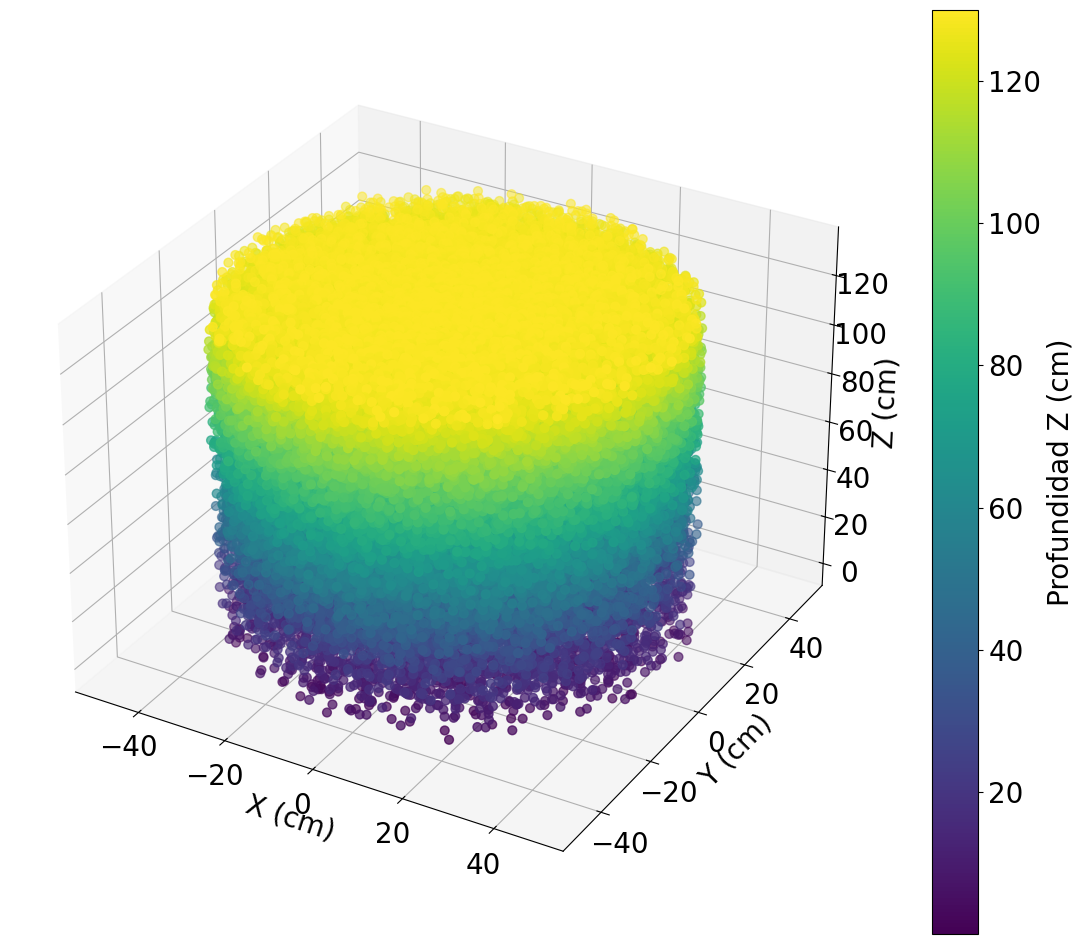

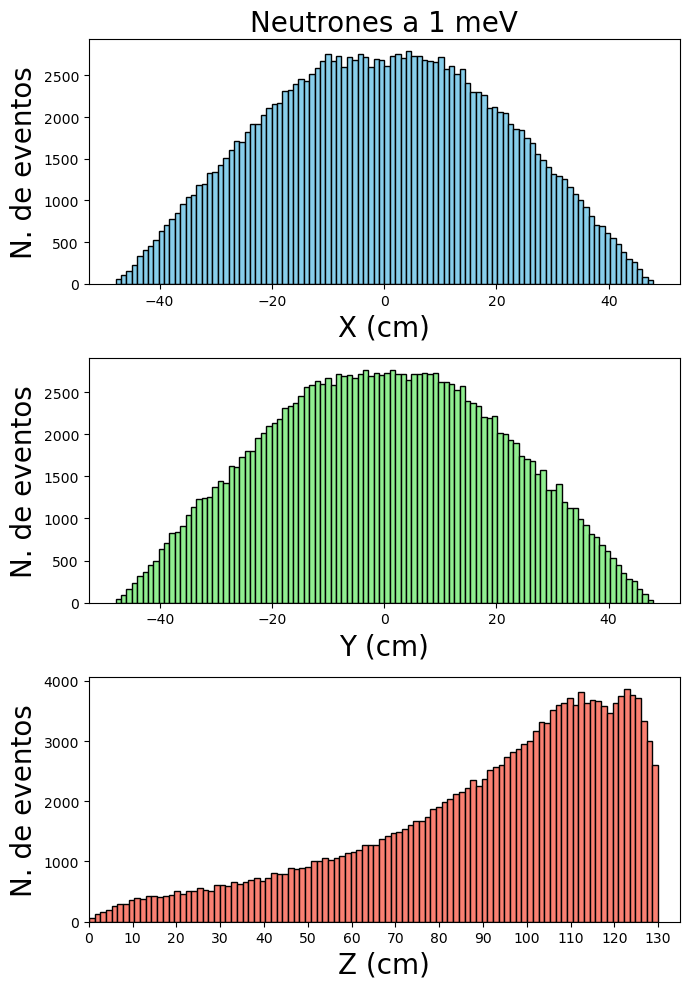

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Archivo de entrada
input_file = "neutrones-capturados-limpio-A5NaCl.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 11 and columnas[4] == "nCapture":
            # Conversión de mm a cm
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

# ====== Gráfico 3D ======
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=40)

ax.set_xlabel("X (cm)", fontsize=20)
ax.set_ylabel("Y (cm)", fontsize=20)
ax.set_zlabel("Z (cm)", fontsize=20)
ax.set_title("", fontsize=16)
ax.tick_params(labelsize=20)  # Aplica a todos los ejes


# Colorbar con tamaño de letra modificado
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Profundidad Z (cm)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig('Coordenadas-neutrones-capturados-A5NaCl-flujo-compl.png', format='jpg')
plt.savefig('Coordenadas-neutrones-capturados-A5NaCl-flujo-compl.pdf', format='pdf')
plt.show()

# ====== Histogramas individuales ======
fig, axes = plt.subplots(3, 1, figsize=(7,10))

# Distribución en X
axes[0].hist(x, bins=100, color="skyblue", edgecolor="black")
axes[0].set_xlabel("X (cm)", fontsize=20)
axes[0].set_ylabel("N. de eventos", fontsize=20)
axes[0].set_title("Neutrones a 1 meV", fontsize=20)

# Distribución en Y
axes[1].hist(y, bins=100, color="lightgreen", edgecolor="black")
axes[1].set_xlabel("Y (cm)", fontsize=20)
axes[1].set_ylabel("N. de eventos", fontsize=20)
axes[1].set_title("", fontsize=14)

# Distribución en Z
axes[2].hist(z, bins=100, color="salmon", edgecolor="black")
axes[2].set_xlabel("Z (cm)", fontsize=20)
axes[2].set_ylabel("N. de eventos", fontsize=20)
axes[2].set_title("", fontsize=14)
# Configurar eje Z de 0 a 135 en pasos de 20
axes[2].set_xlim(0, 135)
axes[2].set_xticks(range(0, 140, 10))

plt.tight_layout()
plt.savefig('Histogramas.Coordenadas-neutrones-capturados-A5NaCl-flujo-compl.png', format='png')
plt.savefig('Histogramas-Coordenadas-neutrones-capturados-A5NaCl-flujo-compl.pdf', format='pdf')
plt.show()


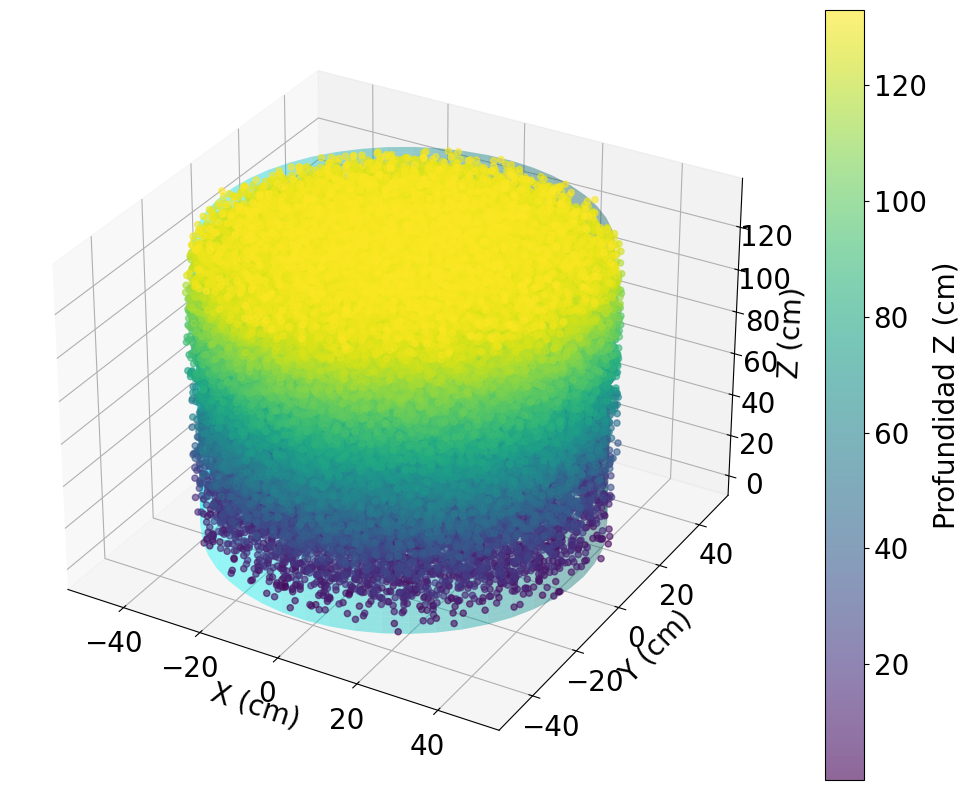

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations

# ========================
# LECTURA DE ARCHIVO
# ========================
input_file = "neutrones-capturados-limpio-A5NaCl.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 11 and columnas[4] == "nCapture":
            x.append(float(columnas[5]) / 10.0)  # Col 6
            y.append(float(columnas[6]) / 10.0)  # Col 7
            z.append(float(columnas[7]) / 10.0)  # Col 8

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# BUSCAR LA REGIÓN MÁS DENSA (histograma 3D)
# ========================
bins = 20
H, edges = np.histogramdd(np.vstack([x, y, z]).T, bins=bins)
idx_max = np.unravel_index(np.argmax(H), H.shape)

x_min, x_max = edges[0][idx_max[0]], edges[0][idx_max[0]+1]
y_min, y_max = edges[1][idx_max[1]], edges[1][idx_max[1]+1]
z_min, z_max = edges[2][idx_max[2]], edges[2][idx_max[2]+1]

# ========================
# CONFIGURACIÓN DEL CILINDRO
# ========================
R = 46.0   # cm
H_cil = 133.0  # cm
Z0 = 0.0   # base en z = 0

theta = np.linspace(0, 2*np.pi, 50)
z_cil = np.linspace(Z0, Z0+H_cil, 50)
theta, z_cil = np.meshgrid(theta, z_cil)

X_cil = R * np.cos(theta)
Y_cil = R * np.sin(theta)
Z_cil = z_cil

# ========================
# GRAFICAR
# ========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

# Puntos
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=20, alpha=0.6)

# Cilindro transparente
ax.plot_surface(X_cil, Y_cil, Z_cil, alpha=0.4, color="cyan", linewidth=0)

# Caja de mayor densidad
xx = [x_min, x_max, x_max, x_min, x_min, x_max, x_max, x_min]
yy = [y_min, y_min, y_max, y_max, y_min, y_min, y_max, y_max]
zz = [z_min, z_min, z_min, z_min, z_max, z_max, z_max, z_max]

for i, j in combinations(range(8), 2):
    if sum(np.abs(np.array([xx[i],yy[i],zz[i]]) - np.array([xx[j],yy[j],zz[j]])) > 1e-8) == 1:
        ax.plot([xx[i], xx[j]], [yy[i], yy[j]], [zz[i], zz[j]], color="red", linewidth=2)

ax.text((x_min+x_max)/2, (y_min+y_max)/2, z_max,
        "", color="red", fontsize=12)

# Etiquetas
ax.set_xlabel("X (cm)", fontsize=20)
ax.set_ylabel("Y (cm)", fontsize=20)
ax.set_zlabel("Z (cm)", fontsize=20)
ax.set_title("")
ax.tick_params(labelsize=20)  # Aplica a todos los ejes

# Barra de color
#fig.colorbar(scatter, ax=ax, label="Profundidad Z (cm)", fontsize=20)
# Colorbar con tamaño de letra modificado
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Profundidad Z (cm)", fontsize=20)
cbar.ax.tick_params(labelsize=20)
# ========================
# GUARDAR FIGURA
# ========================
plt.tight_layout()
plt.savefig("Distribucion-espacial-neutrones-capturados-A5NaCl-flujo-compl.png", dpi=300, format="png")
plt.savefig("Distribucion-espacial-neutrones-capturados-A5NaCl-flujo-compl.pdf", format="pdf")
plt.show()


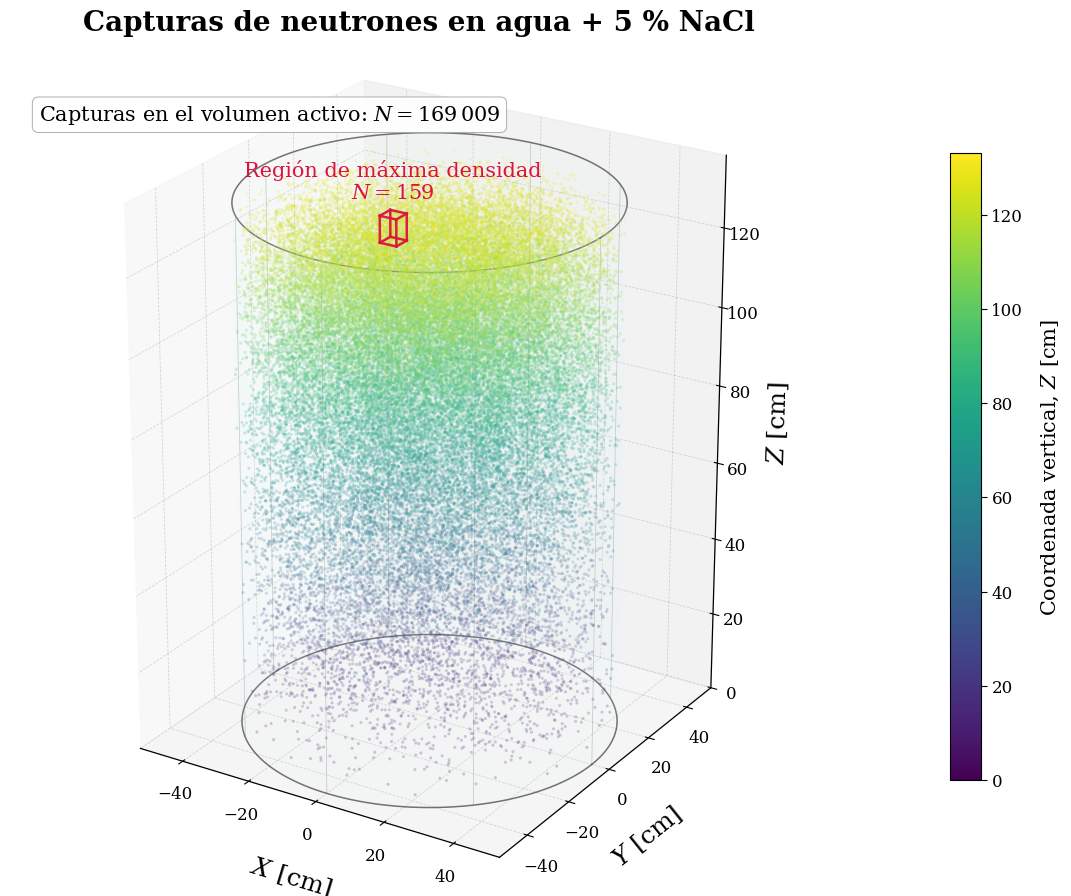

Figura generada correctamente.
Capturas totales leídas: 169019
Capturas dentro del volumen activo: 169009
Capturas fuera del volumen activo: 10
Puntos utilizados para la visualización: 50000
Líneas inválidas o incompletas: 0
Celda de mayor densidad:
  X = [-14.40, -9.60] cm
  Y = [0.00, 4.80] cm
  Z = [119.70, 126.35] cm
  Número de capturas = 159
PNG: Distribucion-espacial-capturas/Distribucion_espacial_capturas_agua_5NaCl.png
PDF: Distribucion-espacial-capturas/Distribucion_espacial_capturas_agua_5NaCl.pdf


In [2]:
import os
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.cm import ScalarMappable


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

INPUT_FILE = "neutrones-capturados-limpio-A5NaCl.txt"

OUTDIR = "Distribucion-espacial-capturas"
os.makedirs(OUTDIR, exist_ok=True)

OUTPUT_PNG = os.path.join(
    OUTDIR,
    "Distribucion_espacial_capturas_agua_5NaCl.png"
)

OUTPUT_PDF = os.path.join(
    OUTDIR,
    "Distribucion_espacial_capturas_agua_5NaCl.pdf"
)

# Geometría del volumen activo
RADIO_CILINDRO = 48.0       # cm
ALTURA_CILINDRO = 133.0     # cm
Z_BASE = 0.0                # cm
Z_SUPERIOR = Z_BASE + ALTURA_CILINDRO

# Configuración del histograma tridimensional
NUMERO_BINS_DENSIDAD = 20

# Número máximo de puntos mostrados.
# Todos los datos se conservan para los cálculos.
MAX_PUNTOS_GRAFICA = 50_000

# Mostrar o no la celda de mayor densidad
MOSTRAR_REGION_DENSA = True

# Semilla para que el muestreo sea reproducible
SEMILLA = 12345


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 0.9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# LECTURA DE LAS POSICIONES DE CAPTURA
# ==========================================================

def leer_posiciones_captura(nombre_archivo):
    """
    Lee las posiciones X, Y y Z de los procesos nCapture.

    Se asume que:
        columna 5: nombre del proceso;
        columna 6: coordenada X en mm;
        columna 7: coordenada Y en mm;
        columna 8: coordenada Z en mm.

    Las coordenadas se convierten de milímetros a centímetros.
    """

    posiciones_x = []
    posiciones_y = []
    posiciones_z = []

    lineas_invalidas = 0

    with open(nombre_archivo, "r", encoding="utf-8") as archivo:

        for numero_linea, linea in enumerate(archivo, start=1):

            columnas = linea.split()

            if len(columnas) < 11:
                lineas_invalidas += 1
                continue

            if columnas[4] != "nCapture":
                continue

            try:
                posiciones_x.append(float(columnas[5]) / 10.0)
                posiciones_y.append(float(columnas[6]) / 10.0)
                posiciones_z.append(float(columnas[7]) / 10.0)

            except ValueError:
                lineas_invalidas += 1
                continue

    x = np.asarray(posiciones_x, dtype=float)
    y = np.asarray(posiciones_y, dtype=float)
    z = np.asarray(posiciones_z, dtype=float)

    mascara_finita = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(z)
    )

    x = x[mascara_finita]
    y = y[mascara_finita]
    z = z[mascara_finita]

    return x, y, z, lineas_invalidas


x, y, z, lineas_invalidas = leer_posiciones_captura(INPUT_FILE)

if len(x) == 0:
    raise RuntimeError(
        "No se encontraron posiciones asociadas al proceso nCapture."
    )


# ==========================================================
# SELECCIÓN DE EVENTOS DENTRO DEL VOLUMEN ACTIVO
# ==========================================================

radio_evento = np.sqrt(x**2 + y**2)

mascara_volumen = (
    (radio_evento <= RADIO_CILINDRO)
    & (z >= Z_BASE)
    & (z <= Z_SUPERIOR)
)

x_interior = x[mascara_volumen]
y_interior = y[mascara_volumen]
z_interior = z[mascara_volumen]

numero_total = len(x)
numero_interior = len(x_interior)
numero_exterior = numero_total - numero_interior

if numero_interior == 0:
    raise RuntimeError(
        "No se encontraron capturas dentro del volumen activo definido."
    )


# ==========================================================
# BÚSQUEDA DE LA CELDA DE MAYOR DENSIDAD
# ==========================================================

datos_3d = np.column_stack((
    x_interior,
    y_interior,
    z_interior
))

histograma_3d, bordes = np.histogramdd(
    datos_3d,
    bins=NUMERO_BINS_DENSIDAD,
    range=[
        [-RADIO_CILINDRO, RADIO_CILINDRO],
        [-RADIO_CILINDRO, RADIO_CILINDRO],
        [Z_BASE, Z_SUPERIOR]
    ]
)

indice_maximo = np.unravel_index(
    np.argmax(histograma_3d),
    histograma_3d.shape
)

x_min = bordes[0][indice_maximo[0]]
x_max = bordes[0][indice_maximo[0] + 1]

y_min = bordes[1][indice_maximo[1]]
y_max = bordes[1][indice_maximo[1] + 1]

z_min = bordes[2][indice_maximo[2]]
z_max = bordes[2][indice_maximo[2] + 1]

capturas_celda_maxima = int(
    histograma_3d[indice_maximo]
)


# ==========================================================
# MUESTREO ÚNICAMENTE PARA LA VISUALIZACIÓN
# ==========================================================

rng = np.random.default_rng(SEMILLA)

if numero_interior > MAX_PUNTOS_GRAFICA:

    indices_muestra = rng.choice(
        numero_interior,
        size=MAX_PUNTOS_GRAFICA,
        replace=False
    )

    x_plot = x_interior[indices_muestra]
    y_plot = y_interior[indices_muestra]
    z_plot = z_interior[indices_muestra]

else:

    x_plot = x_interior
    y_plot = y_interior
    z_plot = z_interior


# ==========================================================
# CONSTRUCCIÓN DEL CILINDRO
# ==========================================================

theta_superficie = np.linspace(
    0.0,
    2.0 * np.pi,
    100
)

z_superficie = np.linspace(
    Z_BASE,
    Z_SUPERIOR,
    50
)

theta_malla, z_malla = np.meshgrid(
    theta_superficie,
    z_superficie
)

x_cilindro = RADIO_CILINDRO * np.cos(theta_malla)
y_cilindro = RADIO_CILINDRO * np.sin(theta_malla)
z_cilindro = z_malla

# Contornos superior e inferior
theta_contorno = np.linspace(
    0.0,
    2.0 * np.pi,
    300
)

x_contorno = RADIO_CILINDRO * np.cos(theta_contorno)
y_contorno = RADIO_CILINDRO * np.sin(theta_contorno)


# ==========================================================
# FUNCIÓN PARA DIBUJAR LA CELDA MÁS DENSA
# ==========================================================

def dibujar_caja_3d(
    eje,
    xmin,
    xmax,
    ymin,
    ymax,
    zmin,
    zmax
):
    """
    Dibuja los doce bordes de un paralelepípedo rectangular.
    """

    vertices = np.array([
        [xmin, ymin, zmin],
        [xmax, ymin, zmin],
        [xmax, ymax, zmin],
        [xmin, ymax, zmin],
        [xmin, ymin, zmax],
        [xmax, ymin, zmax],
        [xmax, ymax, zmax],
        [xmin, ymax, zmax]
    ])

    for i, j in combinations(range(8), 2):

        diferencias = np.abs(
            vertices[i] - vertices[j]
        )

        # Dos vértices forman una arista cuando difieren
        # únicamente en una coordenada.
        if np.count_nonzero(diferencias > 1.0e-10) == 1:

            eje.plot(
                [vertices[i, 0], vertices[j, 0]],
                [vertices[i, 1], vertices[j, 1]],
                [vertices[i, 2], vertices[j, 2]],
                linestyle="-",
                linewidth=1.8,
                color="crimson",
                alpha=0.95,
                zorder=10
            )


# ==========================================================
# CREACIÓN DE LA FIGURA
# ==========================================================

fig = plt.figure(
    figsize=(12.5, 9.5)
)

# Se reserva espacio lateral para la barra de colores
ax = fig.add_axes(
    [0.04, 0.07, 0.78, 0.86],
    projection="3d"
)


# ==========================================================
# SUPERFICIE TRANSPARENTE DEL VOLUMEN ACTIVO
# ==========================================================

ax.plot_surface(
    x_cilindro,
    y_cilindro,
    z_cilindro,
    color="lightcyan",
    alpha=0.075,
    linewidth=0,
    antialiased=True,
    shade=False,
    zorder=0
)

# Contorno inferior
ax.plot(
    x_contorno,
    y_contorno,
    np.full_like(x_contorno, Z_BASE),
    color="0.25",
    linewidth=1.1,
    alpha=0.75
)

# Contorno superior
ax.plot(
    x_contorno,
    y_contorno,
    np.full_like(x_contorno, Z_SUPERIOR),
    color="0.25",
    linewidth=1.1,
    alpha=0.75
)

# Generatrices verticales para hacer visible la geometría
for angulo in np.linspace(0.0, 2.0 * np.pi, 9)[:-1]:

    x_linea = RADIO_CILINDRO * np.cos(angulo)
    y_linea = RADIO_CILINDRO * np.sin(angulo)

    ax.plot(
        [x_linea, x_linea],
        [y_linea, y_linea],
        [Z_BASE, Z_SUPERIOR],
        color="0.40",
        linewidth=0.55,
        alpha=0.35
    )


# ==========================================================
# DISPERSIÓN DE POSICIONES DE CAPTURA
# ==========================================================

normalizacion = colors.Normalize(
    vmin=Z_BASE,
    vmax=Z_SUPERIOR
)

scatter = ax.scatter(
    x_plot,
    y_plot,
    z_plot,
    c=z_plot,
    cmap="viridis",
    norm=normalizacion,
    marker="o",
    s=5,
    alpha=0.24,
    linewidths=0,
    depthshade=False,
    rasterized=True,
    zorder=3
)


# ==========================================================
# CELDA DE MAYOR DENSIDAD
# ==========================================================

if MOSTRAR_REGION_DENSA:

    dibujar_caja_3d(
        ax,
        x_min,
        x_max,
        y_min,
        y_max,
        z_min,
        z_max
    )

    ax.text(
        0.5 * (x_min + x_max),
        0.5 * (y_min + y_max),
        z_max + 3.0,
        (
            "Región de máxima densidad\n"
            f"$N={capturas_celda_maxima}$"
        ),
        fontsize=15,
        color="crimson",
        ha="center",
        va="bottom",
        zorder=15
    )


# ==========================================================
# FORMATO DE LOS EJES
# ==========================================================

margen_xy = 5.0

ax.set_xlim(
    -RADIO_CILINDRO - margen_xy,
    RADIO_CILINDRO + margen_xy
)

ax.set_ylim(
    -RADIO_CILINDRO - margen_xy,
    RADIO_CILINDRO + margen_xy
)

ax.set_zlim(
    Z_BASE,
    Z_SUPERIOR + 5.0
)

ax.set_xlabel(
    r"$X$ [cm]",
    labelpad=12
)

ax.set_ylabel(
    r"$Y$ [cm]",
    labelpad=12
)

ax.set_zlabel(
    r"$Z$ [cm]",
    labelpad=11
)

# Relación geométrica proporcional a las dimensiones físicas
ax.set_box_aspect((
    2.0 * RADIO_CILINDRO,
    2.0 * RADIO_CILINDRO,
    ALTURA_CILINDRO
))

# Perspectiva de la cámara
ax.view_init(
    elev=24,
    azim=-58
)

# Aleja ligeramente la cámara para evitar saturar el panel
try:
    ax.dist = 10.5
except AttributeError:
    pass

ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    pad=3
)

# Rejilla tenue
ax.grid(True)

for eje in [ax.xaxis, ax.yaxis, ax.zaxis]:

    eje._axinfo["grid"]["color"] = (0.45, 0.45, 0.45, 0.28)
    eje._axinfo["grid"]["linewidth"] = 0.55
    eje._axinfo["grid"]["linestyle"] = "--"


# ==========================================================
# TÍTULO E INFORMACIÓN COMPLEMENTARIA
# ==========================================================

ax.set_title(
    "Capturas de neutrones en agua + 5 % NaCl",
    fontsize=20,
    fontweight="semibold",
    pad=20
)

ax.text2D(
    0.035,
    0.945,
    (
        f"Capturas en el volumen activo: "
        f"$N={numero_interior:,}$"
    ).replace(",", r"\,"),
    transform=ax.transAxes,
    fontsize=15,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.7,
        alpha=0.90
    )
)


# ==========================================================
# BARRA DE COLOR INDEPENDIENTE
# ==========================================================

cax = fig.add_axes(
    [0.855, 0.17, 0.025, 0.66]
)

mapeador = ScalarMappable(
    norm=normalizacion,
    cmap="viridis"
)

mapeador.set_array([])

colorbar = fig.colorbar(
    mapeador,
    cax=cax
)

colorbar.set_label(
    r"Coordenada vertical, $Z$ [cm]",
    fontsize=15,
    labelpad=12
)

colorbar.ax.tick_params(
    labelsize=12,
    length=4
)

colorbar.outline.set_linewidth(
    0.8
)


# ==========================================================
# GUARDAR LA FIGURA
# ==========================================================

fig.savefig(
    OUTPUT_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08
)

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()
plt.close(fig)


# ==========================================================
# RESUMEN EN TERMINAL
# ==========================================================

print("Figura generada correctamente.")
print(f"Capturas totales leídas: {numero_total}")
print(f"Capturas dentro del volumen activo: {numero_interior}")
print(f"Capturas fuera del volumen activo: {numero_exterior}")
print(f"Puntos utilizados para la visualización: {len(x_plot)}")
print(f"Líneas inválidas o incompletas: {lineas_invalidas}")

print(
    "Celda de mayor densidad:"
)

print(
    f"  X = [{x_min:.2f}, {x_max:.2f}] cm"
)

print(
    f"  Y = [{y_min:.2f}, {y_max:.2f}] cm"
)

print(
    f"  Z = [{z_min:.2f}, {z_max:.2f}] cm"
)

print(
    f"  Número de capturas = {capturas_celda_maxima}"
)

print(f"PNG: {OUTPUT_PNG}")
print(f"PDF: {OUTPUT_PDF}")

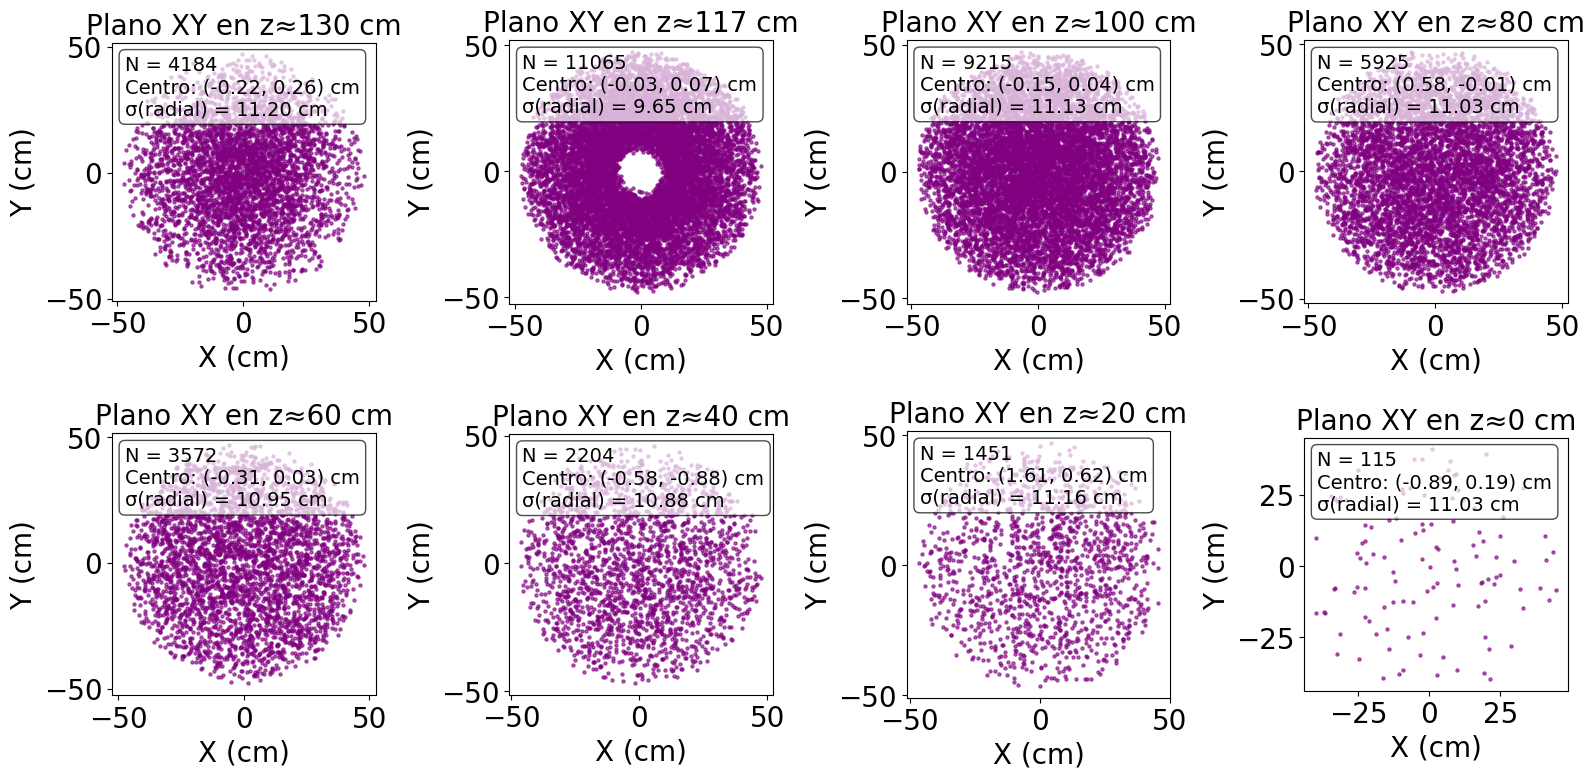

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ========================
# Lectura del archivo
# ========================
x_vals, y_vals, z_vals = [], [], []
with open("neutrones-capturados-limpio-A5NaCl.txt", "r") as f:
    for line in f:
        if line.strip():  # evitar líneas vacías
            cols = line.split()
            # convertir primero a float y luego dividir entre 10
            x_vals.append(float(cols[5]) / 10.0)  # columna 6 -> x (cm)
            y_vals.append(float(cols[6]) / 10.0)  # columna 7 -> y (cm)
            z_vals.append(float(cols[7]) / 10.0)  # columna 8 -> z (cm)

x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
z_vals = np.array(z_vals)

# ========================
# Definir planos Z de interés (en cm)
# ========================
planos_z = [130, 117, 100, 80, 60, 40, 20, 0]

# ========================
# Graficar matriz 2x4
# ========================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

tolerancia = 2  # rango de ± alrededor del valor z para filtrar puntos

for i, z0 in enumerate(planos_z):
    mask = (z_vals >= z0 - tolerancia) & (z_vals <= z0 + tolerancia)
    x_sel, y_sel = x_vals[mask], y_vals[mask]

    # Graficar puntos en rojo
    axes[i].scatter(x_sel, y_sel, s=5, alpha=0.6, color="purple")
    axes[i].set_title(f"Plano XY en z≈{z0} cm", fontsize=20)
    axes[i].set_xlabel("X (cm)", fontsize=20)
    axes[i].set_ylabel("Y (cm)", fontsize=20)
    axes[i].set_aspect("equal")
    axes[i].tick_params(labelsize=20)  # Aplica a todos los ejes

    # ========================
    # Estadísticas por plano
    # ========================
    n_eventos = len(x_sel)
    if n_eventos > 0:
        mean_x, mean_y = np.mean(x_sel), np.mean(y_sel)
        # distancia radial al centroide
        distancias = np.sqrt((x_sel - mean_x)**2 + (y_sel - mean_y)**2)
        std_radial = np.std(distancias)

        # Texto resumen
        texto = (
            f"N = {n_eventos}\n"
            f"Centro: ({mean_x:.2f}, {mean_y:.2f}) cm\n"
            f"σ(radial) = {std_radial:.2f} cm"
        )

        # Mostrar recuadro
        axes[i].text(
            0.05, 0.95, texto,
            transform=axes[i].transAxes,
            fontsize=14,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7)
        )

# Ocultar la última gráfica vacía (8° subplot)
#axes[-1].axis("off")

# ========================
# GUARDAR FIGURA
# ========================
plt.tight_layout()
plt.savefig("Scatter-plot-neutrones-capturados-A5NaCl-flujo-sup.png", dpi=300, format="png")
plt.savefig("Scatter-plot-neutrones-capturados-A5NaCl-flujo-sup.pdf", format="pdf")
plt.show()


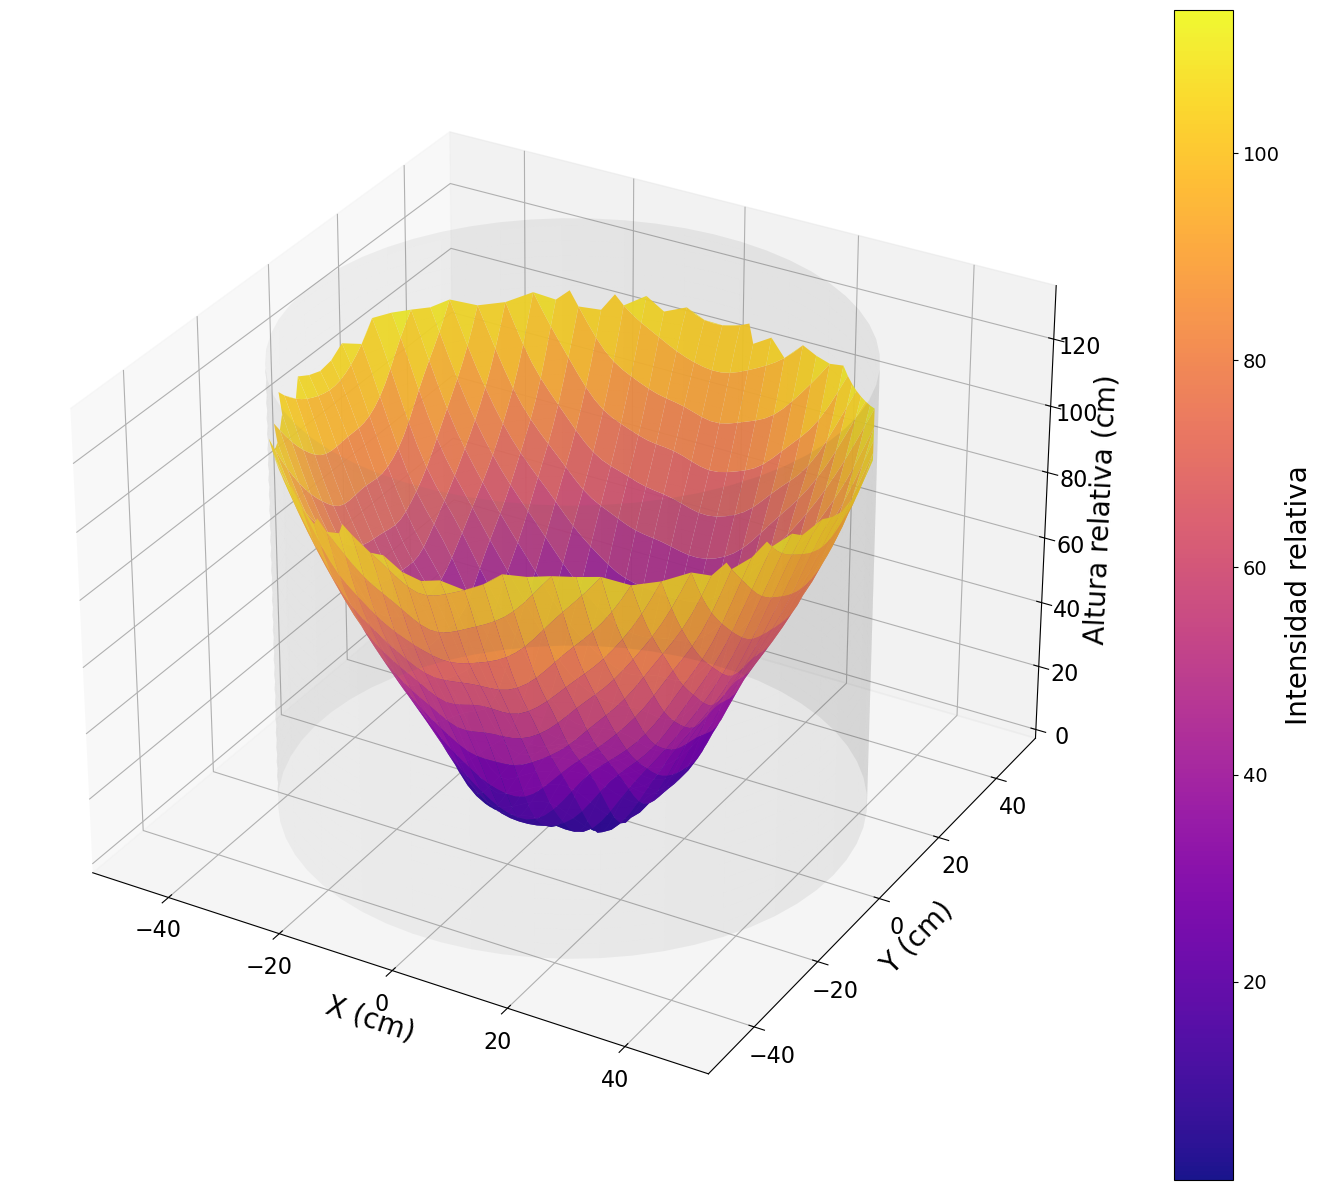

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# ========================
# LECTURA DEL ARCHIVO
# ========================
input_file = "neutrones-capturados-limpio-A5NaCl.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 11 and columnas[4] == "nCapture":
            x.append(float(columnas[5]) / 10.0)  # cm
            y.append(float(columnas[6]) / 10.0)  # cm
            z.append(float(columnas[7]) / 10.0)  # cm

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# MALLA EN EL PLANO XY
# ========================
bins = 60   # resolución de la grilla
H, xedges, yedges = np.histogram2d(x, y, bins=bins)

# Suavizado para efecto de campana
H_smooth = gaussian_filter(H, sigma=2)

# Centros de cada celda
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(xcenters, ycenters)

# Normalizar alturas dentro de la tapa superior del cilindro
R = 46   # radio (cm)
Hc = 133 # altura (cm)
Z = (H_smooth / H_smooth.max()) * Hc  

# Invertir la campana (protuberancias hacia abajo)
Z_invert = Hc - Z

# Enmascarar fuera del cilindro
mask = (X**2 + Y**2) <= R**2
Z_masked = np.where(mask, Z_invert, np.nan)

# ========================
# GRAFICAR SUPERFICIE 3D
# ========================
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z_masked,
                       cmap="plasma",
                       edgecolor="none",
                       alpha=0.95)

# Dibujar cilindro transparente
theta = np.linspace(0, 2*np.pi, 60)
z_cil = np.linspace(0, Hc, 60)
theta_grid, z_grid = np.meshgrid(theta, z_cil)
x_cil = R * np.cos(theta_grid)
y_cil = R * np.sin(theta_grid)

ax.plot_surface(x_cil, y_cil, z_grid, alpha=0.08, color="gray")


# Etiquetas
ax.set_xlabel("X (cm)", fontsize=20)
ax.set_ylabel("Y (cm)", fontsize=20)
ax.set_zlabel("Altura relativa (cm)", fontsize=20)
ax.set_title("")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.grid(axis="x", linestyle="--", alpha=0.7)
ax.tick_params(axis='x', which='both', labelsize=16)
ax.tick_params(axis='y', which='both', labelsize=16)
ax.tick_params(axis='z', which='both', labelsize=16)
# Barra de colores
#fig.colorbar(surf, ax=ax, label="Intensidad relativa")
cbar = fig.colorbar(surf, ax=ax, label="Intensidad relativa")
cbar.set_label("Intensidad relativa", fontsize=20)   # tamaño del título
cbar.ax.tick_params(labelsize=14)                   # tamaño de los números

# ========================
# GUARDAR FIGURA
# ========================
plt.tight_layout()
plt.savefig("Superficie-neutrones-capturados-A5NaCl-flujo-compl.png", dpi=300, format="png")
plt.savefig("Superficie-neutrones-capturados-A5NaCl-flujo-compl.pdf", format="pdf")
plt.show()

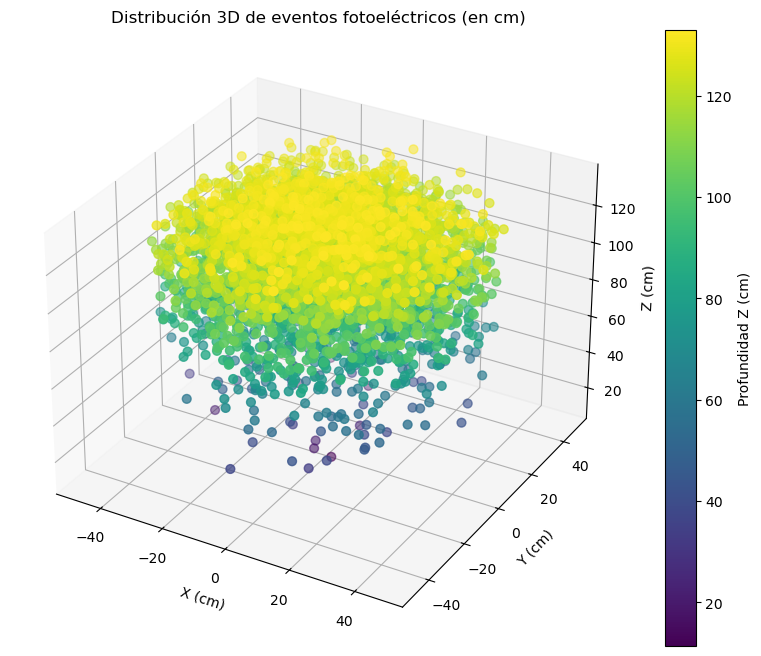

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Archivo de entrada
input_file = "fotoelectrico-completo-1meV.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            # Conversión de mm a cm (dividir entre 10)
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

# Graficar en 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=40)

# Etiquetas
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.set_title("Distribución 3D de eventos fotoeléctricos (en cm)")

# Barra de colores
fig.colorbar(scatter, ax=ax, label="Profundidad Z (cm)")

plt.show()


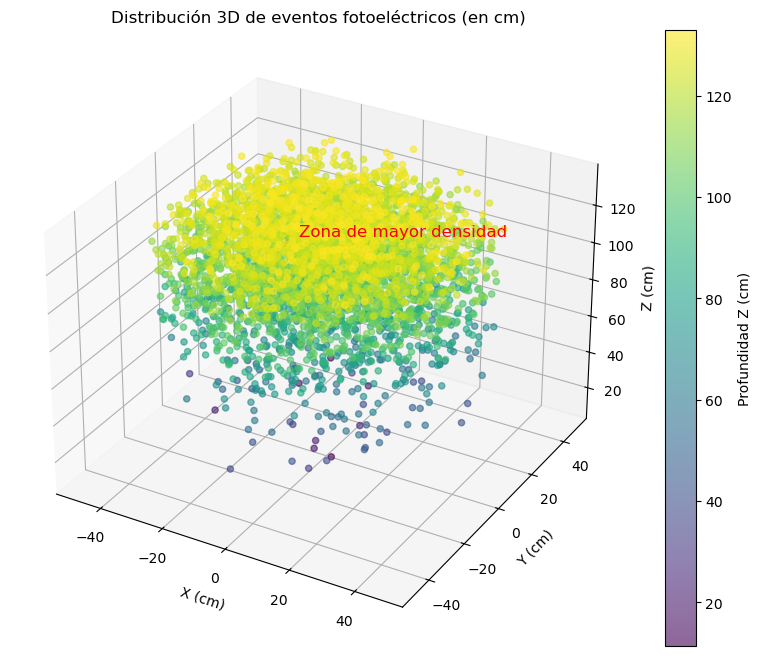

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Archivo de entrada
input_file = "fotoelectrico-completo-1meV.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            # Conversión de mm a cm
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# BUSCAR LA REGIÓN MÁS DENSA
# ========================
bins = 20  # número de divisiones por eje
H, edges = np.histogramdd(np.vstack([x, y, z]).T, bins=bins)

# Índice de la celda más poblada
idx_max = np.unravel_index(np.argmax(H), H.shape)

# Rango de la celda más densa
x_min, x_max = edges[0][idx_max[0]], edges[0][idx_max[0]+1]
y_min, y_max = edges[1][idx_max[1]], edges[1][idx_max[1]+1]
z_min, z_max = edges[2][idx_max[2]], edges[2][idx_max[2]+1]

# ========================
# GRAFICAR DISTRIBUCIÓN 3D
# ========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=20, alpha=0.6)

# Etiquetas
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.set_title("Distribución 3D de eventos fotoeléctricos (en cm)")

# Barra de colores
fig.colorbar(scatter, ax=ax, label="Profundidad Z (cm)")

# ========================
# DIBUJAR LA CAJA DE MAYOR DENSIDAD
# ========================
xx = [x_min, x_max, x_max, x_min, x_min, x_max, x_max, x_min]
yy = [y_min, y_min, y_max, y_max, y_min, y_min, y_max, y_max]
zz = [z_min, z_min, z_min, z_min, z_max, z_max, z_max, z_max]

# Conectar vértices para formar la caja
from itertools import combinations
for i, j in combinations(range(8), 2):
    if sum(np.abs(np.array([xx[i],yy[i],zz[i]]) - np.array([xx[j],yy[j],zz[j]])) > 1e-8) == 1:
        ax.plot([xx[i], xx[j]], [yy[i], yy[j]], [zz[i], zz[j]], color="red", linewidth=2)

# Texto indicando región densa
ax.text((x_min+x_max)/2, (y_min+y_max)/2, z_max, "Zona de mayor densidad", color="red", fontsize=12)

plt.show()


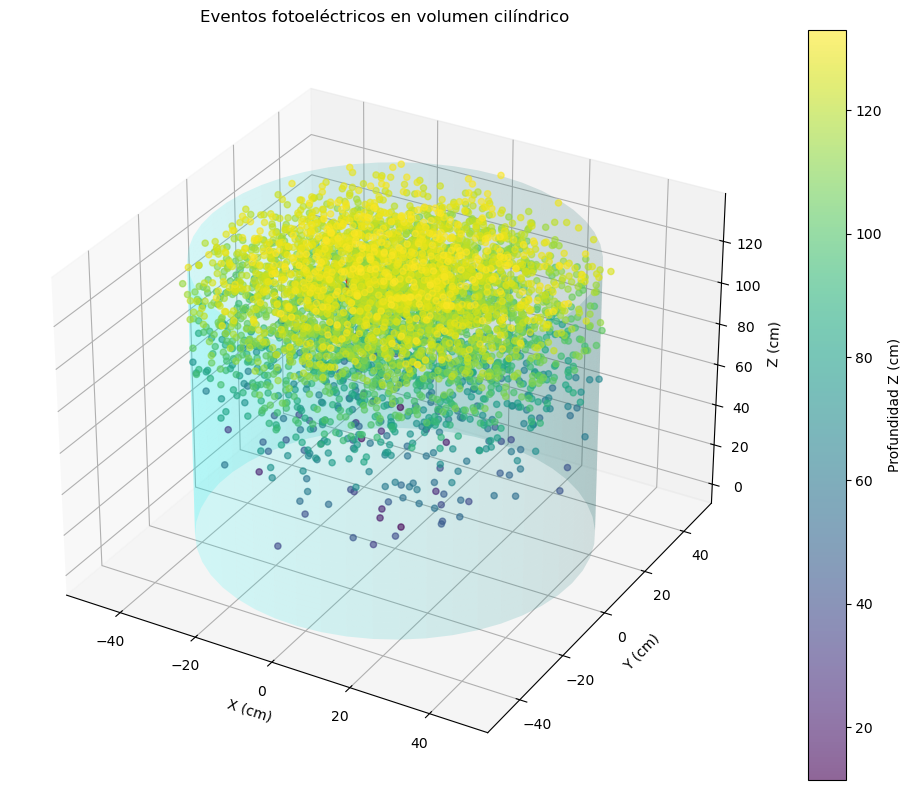

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations

# ========================
# LECTURA DE ARCHIVO
# ========================
input_file = "fotoelectrico-completo-1meV.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            x.append(float(columnas[5]) / 10.0)  # Col 6
            y.append(float(columnas[6]) / 10.0)  # Col 7
            z.append(float(columnas[7]) / 10.0)  # Col 8

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# BUSCAR LA REGIÓN MÁS DENSA (histograma 3D)
# ========================
bins = 20
H, edges = np.histogramdd(np.vstack([x, y, z]).T, bins=bins)
idx_max = np.unravel_index(np.argmax(H), H.shape)

x_min, x_max = edges[0][idx_max[0]], edges[0][idx_max[0]+1]
y_min, y_max = edges[1][idx_max[1]], edges[1][idx_max[1]+1]
z_min, z_max = edges[2][idx_max[2]], edges[2][idx_max[2]+1]

# ========================
# CONFIGURACIÓN DEL CILINDRO
# ========================
R = 46.0   # cm
H_cil = 133.0  # cm
Z0 = 0.0   # base en z = 0

theta = np.linspace(0, 2*np.pi, 50)
z_cil = np.linspace(Z0, Z0+H_cil, 50)
theta, z_cil = np.meshgrid(theta, z_cil)

X_cil = R * np.cos(theta)
Y_cil = R * np.sin(theta)
Z_cil = z_cil

# ========================
# GRAFICAR
# ========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

# Puntos
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=20, alpha=0.6)

# Cilindro transparente
ax.plot_surface(X_cil, Y_cil, Z_cil, alpha=0.15, color="cyan", linewidth=0)

# Caja de mayor densidad
xx = [x_min, x_max, x_max, x_min, x_min, x_max, x_max, x_min]
yy = [y_min, y_min, y_max, y_max, y_min, y_min, y_max, y_max]
zz = [z_min, z_min, z_min, z_min, z_max, z_max, z_max, z_max]

for i, j in combinations(range(8), 2):
    if sum(np.abs(np.array([xx[i],yy[i],zz[i]]) - np.array([xx[j],yy[j],zz[j]])) > 1e-8) == 1:
        ax.plot([xx[i], xx[j]], [yy[i], yy[j]], [zz[i], zz[j]], color="red", linewidth=2)

ax.text((x_min+x_max)/2, (y_min+y_max)/2, z_max,
        "", color="red", fontsize=12)

# Etiquetas
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.set_title("")

# Barra de color
fig.colorbar(scatter, ax=ax, label="Profundidad Z (cm)")
# ========================
# GUARDAR FIGURA
# ========================
plt.tight_layout()
plt.savefig("Distribucion-espacial-efecto-forel-1meV.png", dpi=300, format="png")
plt.savefig("Distribucion-espacial-efecto-forel-1meV-1meV.pdf", format="pdf")
plt.show()


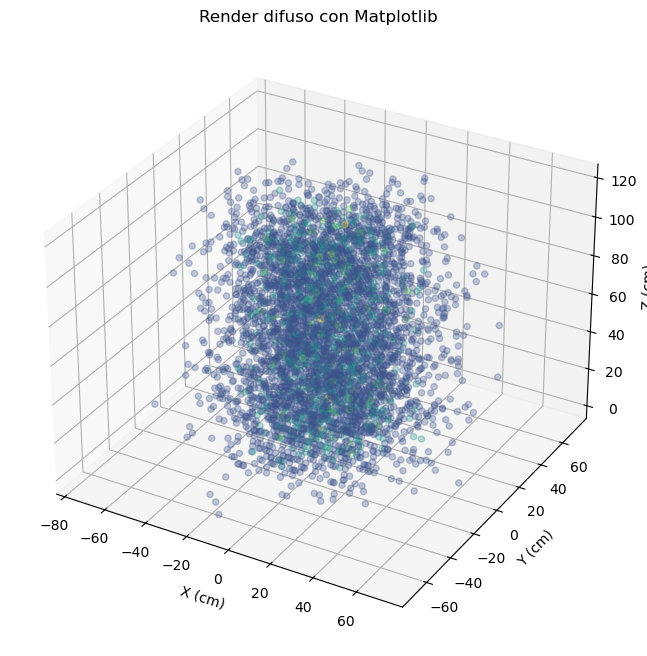

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Datos ficticios de prueba (usa tus x,y,z reales)
N = 5000
x = np.random.normal(0, 20, N)
y = np.random.normal(0, 20, N)
z = np.random.uniform(0, 120, N)

# Voxelización
bins = 40
H, edges = np.histogramdd(np.vstack([x,y,z]).T, bins=bins)

# Normalizar para transparencias
H = H / H.max()

# Crear grilla
xcenters = 0.5*(edges[0][1:] + edges[0][:-1])
ycenters = 0.5*(edges[1][1:] + edges[1][:-1])
zcenters = 0.5*(edges[2][1:] + edges[2][:-1])

X, Y, Z = np.meshgrid(xcenters, ycenters, zcenters, indexing="ij")

# Graficar "nube volumétrica"
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

mask = H > 0.1  # filtrar regiones no vacías
colors = plt.cm.viridis(H[mask])

ax.scatter(X[mask], Y[mask], Z[mask],
           c=colors, s=20, alpha=0.3)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.set_title("Render difuso con Matplotlib")

plt.show()


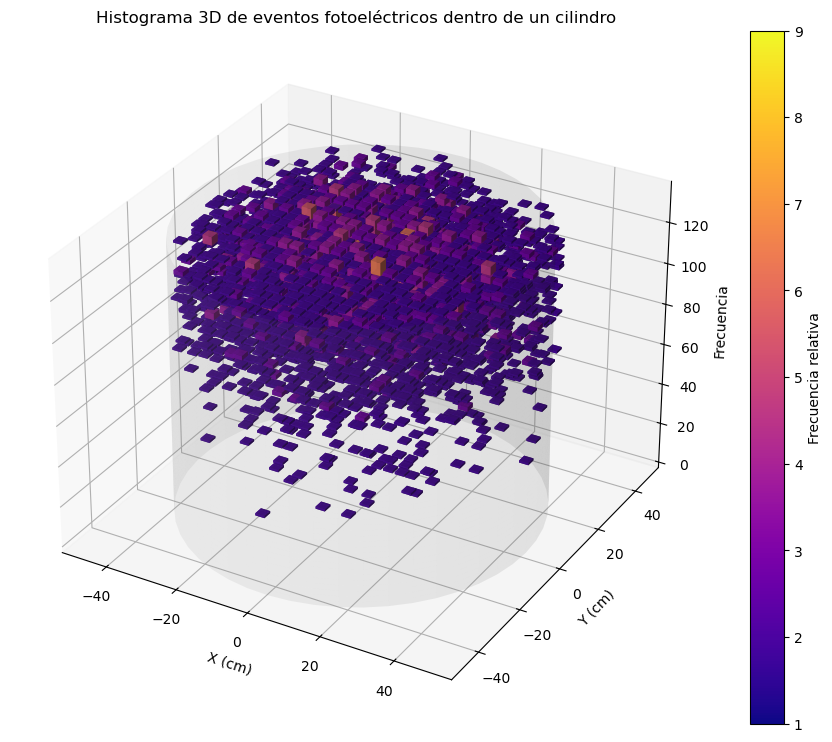

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ========================
# LECTURA DEL ARCHIVO
# ========================
input_file = "fotoelectrico-completo-1meV.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            x.append(float(columnas[5]) / 10.0)  # cm
            y.append(float(columnas[6]) / 10.0)  # cm
            z.append(float(columnas[7]) / 10.0)  # cm

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# HISTOGRAMA 3D
# ========================
bins = 30   # número de divisiones
H, edges = np.histogramdd(np.vstack([x, y, z]).T, bins=bins)

# Centros de cada cubo
xpos, ypos, zpos = np.meshgrid(
    (edges[0][:-1] + edges[0][1:]) / 2,
    (edges[1][:-1] + edges[1][1:]) / 2,
    (edges[2][:-1] + edges[2][1:]) / 2,
    indexing="ij"
)

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = zpos.ravel()
values = H.ravel()

# Filtrar solo bins con contenido
mask_nonzero = values > 0
xpos, ypos, zpos, values = xpos[mask_nonzero], ypos[mask_nonzero], zpos[mask_nonzero], values[mask_nonzero]

# Tamaño de los cubos
dx = dy = (edges[0][1]-edges[0][0]) * 0.8
dz = (edges[2][1]-edges[2][0]) * 0.8

# ========================
# GRAFICAR HISTOGRAMA 3D
# ========================
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Normalizar valores para colores
norm_values = values / values.max() if values.max() > 0 else values
colors = plt.cm.plasma(norm_values)  # plasma: azul → rojo → amarillo intenso

# Filtrar barras que estén dentro del cilindro
R = 46   # radio (cm)
Hc = 133 # altura (cm)
mask_cil = (xpos**2 + ypos**2) <= R**2
xpos, ypos, zpos, values, colors = xpos[mask_cil], ypos[mask_cil], zpos[mask_cil], values[mask_cil], colors[mask_cil]

# Barras dentro del cilindro
ax.bar3d(xpos, ypos, zpos, dx, dy, values, shade=True, color=colors, alpha=0.9)

# ========================
# DIBUJAR CILINDRO TRANSPARENTE
# ========================
theta = np.linspace(0, 2*np.pi, 50)
z_cil = np.linspace(0, Hc, 50)
theta_grid, z_grid = np.meshgrid(theta, z_cil)
x_cil = R * np.cos(theta_grid)
y_cil = R * np.sin(theta_grid)

ax.plot_surface(x_cil, y_cil, z_grid, alpha=0.1, color="gray", linewidth=0)

# Etiquetas
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Frecuencia")
ax.set_title("Histograma 3D de eventos fotoeléctricos dentro de un cilindro")

# Barra de colores opcional
m = plt.cm.ScalarMappable(cmap="plasma")
m.set_array(values)
fig.colorbar(m, ax=ax, label="Frecuencia relativa")

plt.show()


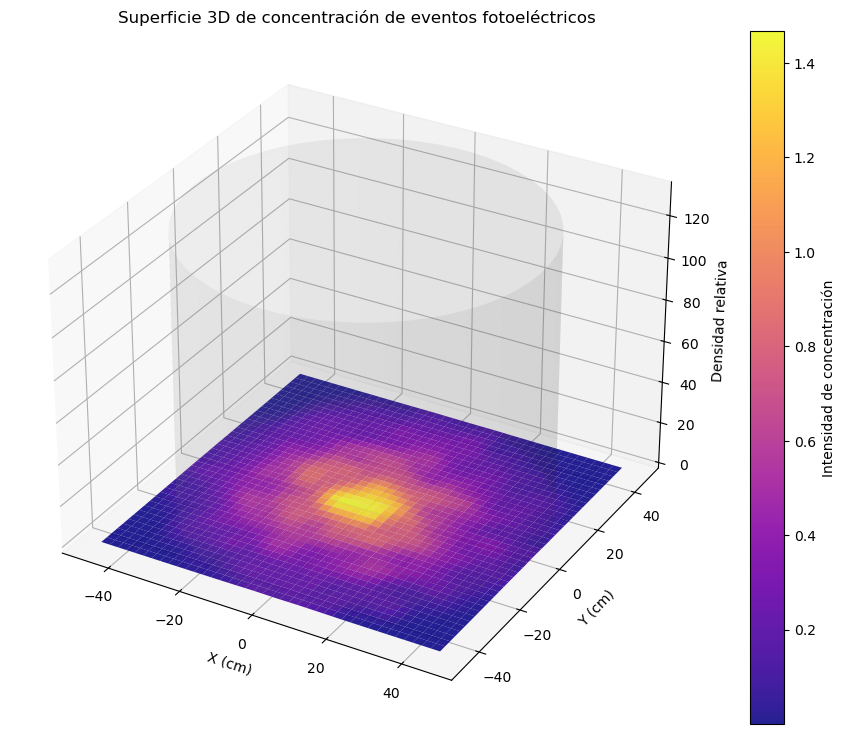

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# ========================
# LECTURA DEL ARCHIVO
# ========================
input_file = "fotoelectrico-completo-1meV.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            x.append(float(columnas[5]) / 10.0)  # cm
            y.append(float(columnas[6]) / 10.0)  # cm
            z.append(float(columnas[7]) / 10.0)  # cm

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# CREAR UNA MALLA 3D
# ========================
bins = 40
H, edges = np.histogramdd(np.vstack([x, y, z]).T, bins=bins)

# Suavizar para dar efecto de superficie continua
H_smooth = gaussian_filter(H, sigma=1.2)

# Generar centros de cada bin
xcenters = (edges[0][:-1] + edges[0][1:]) / 2
ycenters = (edges[1][:-1] + edges[1][1:]) / 2
zcenters = (edges[2][:-1] + edges[2][1:]) / 2

X, Y = np.meshgrid(xcenters, ycenters, indexing="ij")
Z = H_smooth.max(axis=2)  # tomamos el máximo en Z como "altura"

# ========================
# GRAFICAR SUPERFICIE 3D
# ========================
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z,
                       cmap="plasma",
                       edgecolor="none",
                       alpha=0.9)

# ========================
# DIBUJAR CILINDRO TRANSPARENTE
# ========================
R = 46   # radio (cm)
Hc = 133 # altura (cm)
theta = np.linspace(0, 2*np.pi, 60)
z_cil = np.linspace(0, Hc, 60)
theta_grid, z_grid = np.meshgrid(theta, z_cil)
x_cil = R * np.cos(theta_grid)
y_cil = R * np.sin(theta_grid)

ax.plot_surface(x_cil, y_cil, z_grid, alpha=0.08, color="gray")

# Etiquetas
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Densidad relativa")
ax.set_title("Superficie 3D de concentración de eventos fotoeléctricos")

# Barra de colores
fig.colorbar(surf, ax=ax, label="Intensidad de concentración")

plt.show()


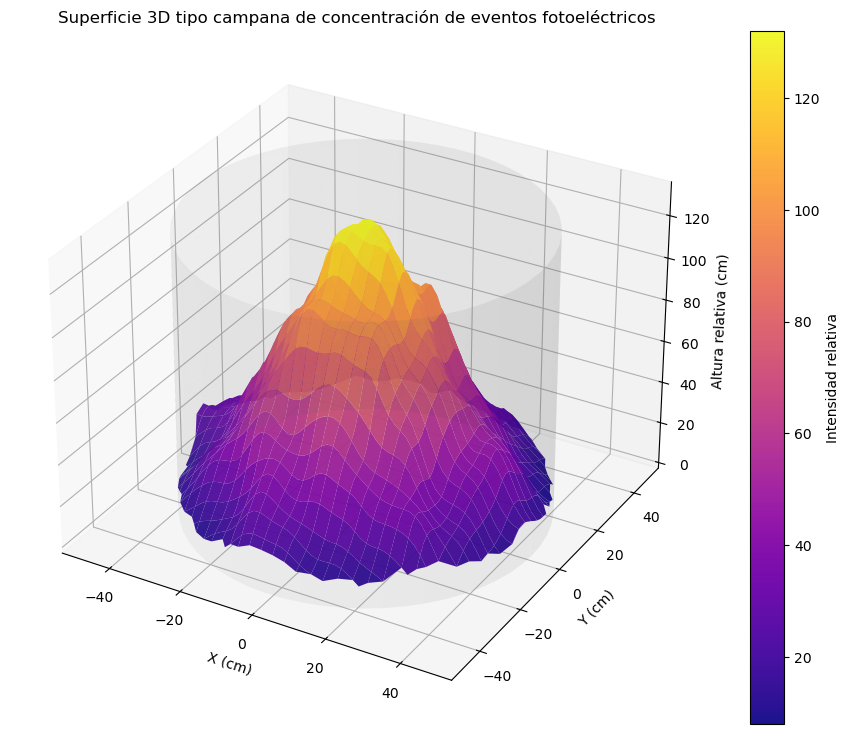

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# ========================
# LECTURA DEL ARCHIVO
# ========================
input_file = "fotoelectrico-completo-1meV.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            x.append(float(columnas[5]) / 10.0)  # cm
            y.append(float(columnas[6]) / 10.0)  # cm
            z.append(float(columnas[7]) / 10.0)  # cm

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# MALLA EN EL PLANO XY
# ========================
bins = 60   # resolución en la grilla
H, xedges, yedges = np.histogram2d(x, y, bins=bins)

# Suavizado para efecto de campana
H_smooth = gaussian_filter(H, sigma=2)

# Centros de cada celda
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(xcenters, ycenters)

# Normalizar alturas dentro de la tapa superior del cilindro
R = 46   # radio (cm)
Hc = 133 # altura (cm)
Z = (H_smooth / H_smooth.max()) * Hc  # escala hasta la tapa

# Enmascarar fuera del cilindro
mask = (X**2 + Y**2) <= R**2
Z_masked = np.where(mask, Z, np.nan)

# ========================
# GRAFICAR SUPERFICIE 3D
# ========================
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z_masked,
                       cmap="plasma",
                       edgecolor="none",
                       alpha=0.95)

# Dibujar cilindro transparente
theta = np.linspace(0, 2*np.pi, 60)
z_cil = np.linspace(0, Hc, 60)
theta_grid, z_grid = np.meshgrid(theta, z_cil)
x_cil = R * np.cos(theta_grid)
y_cil = R * np.sin(theta_grid)

ax.plot_surface(x_cil, y_cil, z_grid, alpha=0.08, color="gray")

# Etiquetas
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Altura relativa (cm)")
ax.set_title("Superficie 3D tipo campana de concentración de eventos fotoeléctricos")

# Barra de colores
fig.colorbar(surf, ax=ax, label="Intensidad relativa")

plt.show()


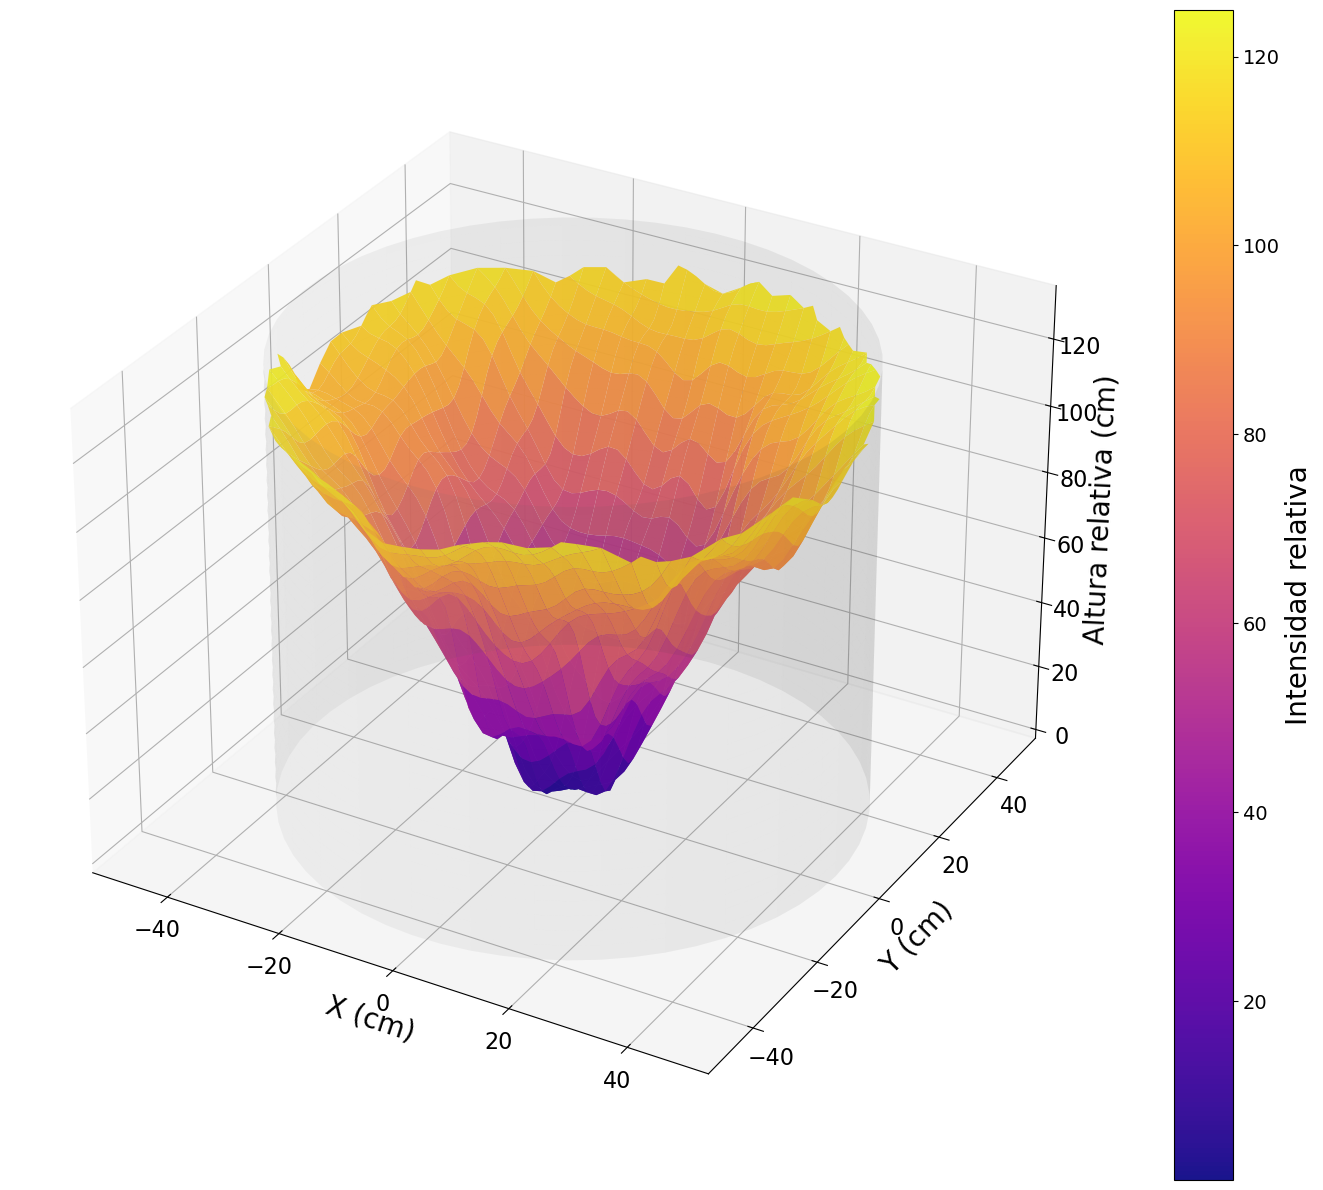

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# ========================
# LECTURA DEL ARCHIVO
# ========================
input_file = "fotoelectrico-completo-1meV.txt"

x, y, z = [], [], []
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            x.append(float(columnas[5]) / 10.0)  # cm
            y.append(float(columnas[6]) / 10.0)  # cm
            z.append(float(columnas[7]) / 10.0)  # cm

x, y, z = np.array(x), np.array(y), np.array(z)

# ========================
# MALLA EN EL PLANO XY
# ========================
bins = 60   # resolución de la grilla
H, xedges, yedges = np.histogram2d(x, y, bins=bins)

# Suavizado para efecto de campana
H_smooth = gaussian_filter(H, sigma=2)

# Centros de cada celda
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(xcenters, ycenters)

# Normalizar alturas dentro de la tapa superior del cilindro
R = 46   # radio (cm)
Hc = 133 # altura (cm)
Z = (H_smooth / H_smooth.max()) * Hc  

# Invertir la campana (protuberancias hacia abajo)
Z_invert = Hc - Z

# Enmascarar fuera del cilindro
mask = (X**2 + Y**2) <= R**2
Z_masked = np.where(mask, Z_invert, np.nan)

# ========================
# GRAFICAR SUPERFICIE 3D
# ========================
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z_masked,
                       cmap="plasma",
                       edgecolor="none",
                       alpha=0.95)

# Dibujar cilindro transparente
theta = np.linspace(0, 2*np.pi, 60)
z_cil = np.linspace(0, Hc, 60)
theta_grid, z_grid = np.meshgrid(theta, z_cil)
x_cil = R * np.cos(theta_grid)
y_cil = R * np.sin(theta_grid)

ax.plot_surface(x_cil, y_cil, z_grid, alpha=0.08, color="gray")


# Etiquetas
ax.set_xlabel("X (cm)", fontsize=20)
ax.set_ylabel("Y (cm)", fontsize=20)
ax.set_zlabel("Altura relativa (cm)", fontsize=20)
ax.set_title("")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.grid(axis="x", linestyle="--", alpha=0.7)
ax.tick_params(axis='x', which='both', labelsize=16)
ax.tick_params(axis='y', which='both', labelsize=16)
ax.tick_params(axis='z', which='both', labelsize=16)
# Barra de colores
#fig.colorbar(surf, ax=ax, label="Intensidad relativa")
cbar = fig.colorbar(surf, ax=ax, label="Intensidad relativa")
cbar.set_label("Intensidad relativa", fontsize=20)   # tamaño del título
cbar.ax.tick_params(labelsize=14)                   # tamaño de los números

# ========================
# GUARDAR FIGURA
# ========================
plt.tight_layout()
plt.savefig("Superficie-Fotoelectrico-1meV.png", dpi=300, format="png")
plt.savefig("Superficie-Fotoelectrico-1meV.pdf", format="pdf")
plt.show()

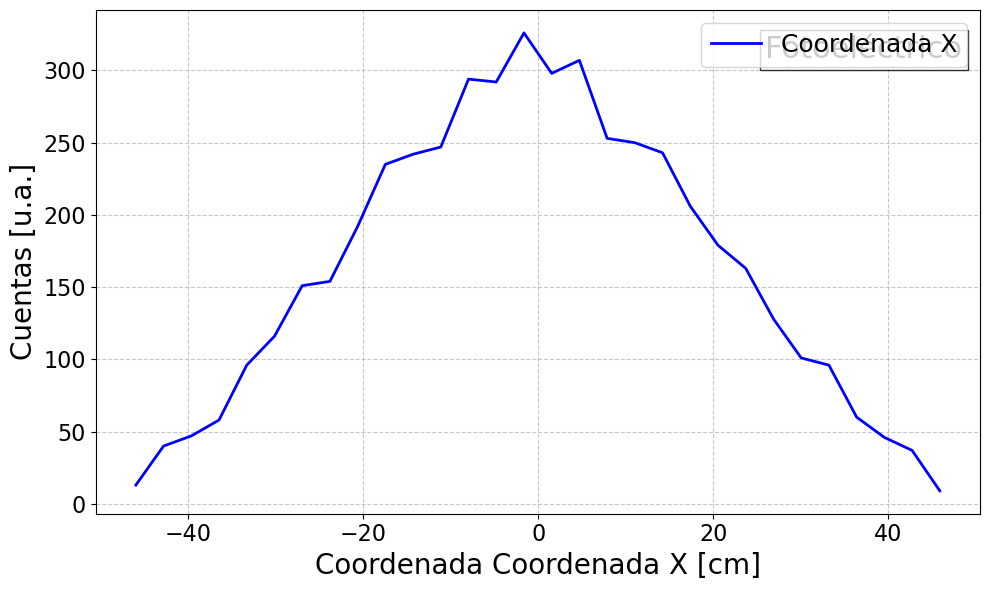

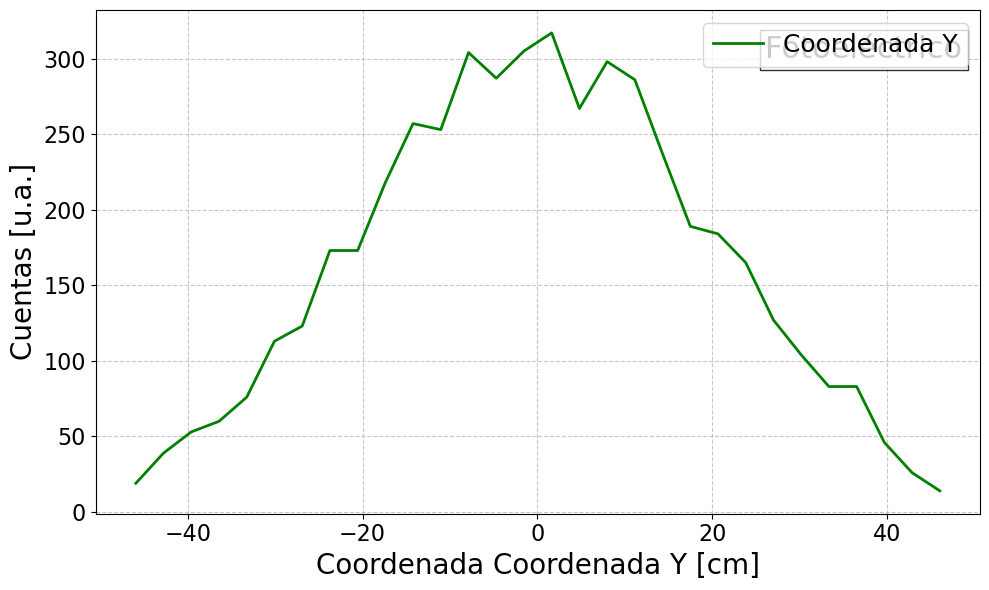

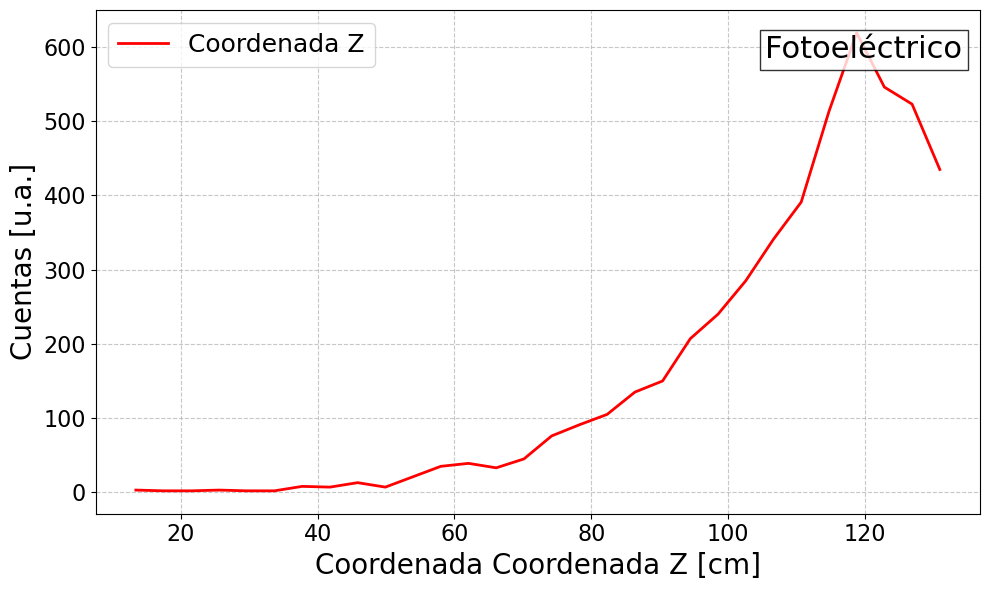

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Archivo de entrada
input_file = "fotoelectrico-completo-1meV.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            # Conversión de mm a cm
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

# ========================
# CONFIGURACIÓN DE POLÍGONOS DE FRECUENCIA
# ========================
numero_bins = 30   # ajusta según tu resolución
colores = {"X": "red", "Y": "red", "Z": "red"}
datos = {"X": x, "Y": y, "Z": z}

def plot_polygon(data, color, label, filename):
    counts, bins = np.histogram(data, bins=numero_bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.figure(figsize=(10, 6))
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

    # Etiquetas y formato
    plt.xlabel(f"Coordenada {label} [cm]", fontsize=20)
    plt.ylabel("Cuentas [u.a.]", fontsize=20)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tick_params(axis='x', which='both', labelsize=16)
    plt.tick_params(axis='y', which='both', labelsize=16)

    # Leyenda
    plt.legend(fontsize=18)

    # Texto adicional
    plt.text(
        0.98, 0.95,
        "Fotoeléctrico",
        transform=plt.gca().transAxes,
        fontsize=22,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )

    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig(f"{filename}.png", dpi=300, format="png")
    plt.savefig(f"{filename}.pdf", format="pdf")
    plt.show()

# ========================
# GRAFICAR CADA COORDENADA POR SEPARADO
# ========================
plot_polygon(x, color=colores["X"], label="Coordenada X", filename="Distribucion-Fotoelectrico-X")
plot_polygon(y, color=colores["Y"], label="Coordenada Y", filename="Distribucion-Fotoelectrico-Y")
plot_polygon(z, color=colores["Z"], label="Coordenada Z", filename="Distribucion-Fotoelectrico-Z")


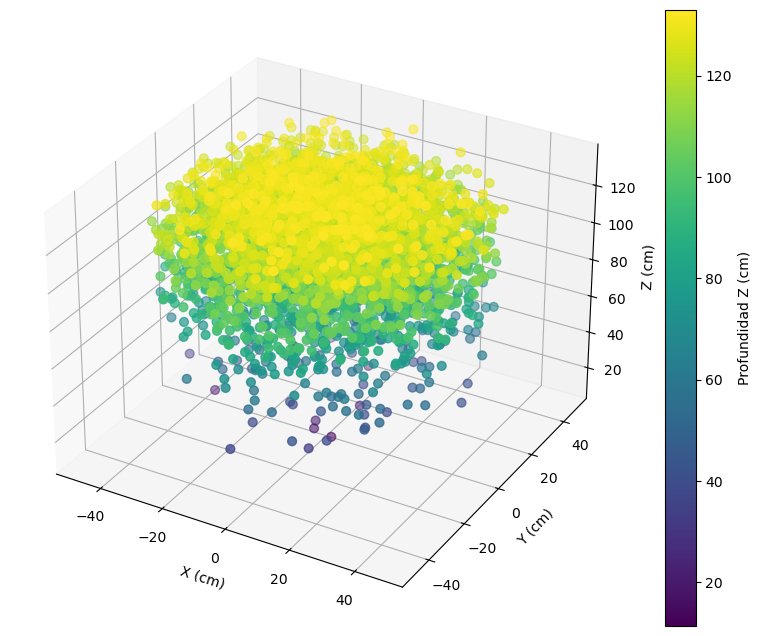

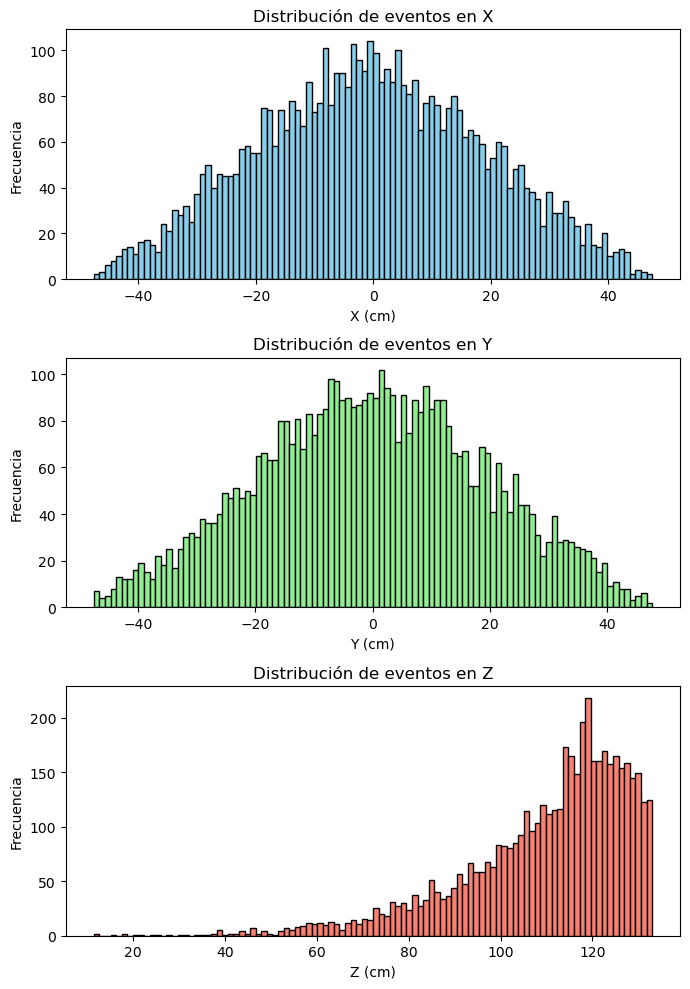

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Archivo de entrada
input_file = "fotoelectrico-completo-1meV.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            # Conversión de mm a cm
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

# ====== Gráfico 3D ======
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=40)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.set_title("")

fig.colorbar(scatter, ax=ax, label="Profundidad Z (cm)")
#plt.tight_layout()
plt.savefig('Coordenadas-Fotoelectrico-1meV.png', format='jpg')
plt.savefig('Coordenadas-Fotoelectrico-1meV.pdf', format='pdf')
plt.show()

# ====== Histogramas individuales ======
fig, axes = plt.subplots(3, 1, figsize=(7,10))

# Distribución en X
axes[0].hist(x, bins=100, color="skyblue", edgecolor="black")
axes[0].set_xlabel("X (cm)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de eventos en X")

# Distribución en Y
axes[1].hist(y, bins=100, color="lightgreen", edgecolor="black")
axes[1].set_xlabel("Y (cm)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de eventos en Y")

# Distribución en Z
axes[2].hist(z, bins=100, color="salmon", edgecolor="black")
axes[2].set_xlabel("Z (cm)")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Distribución de eventos en Z")

plt.tight_layout()
plt.savefig('Histogramas.Coordenadas-Fotoelectrico-1meV.png', format='jpg')
plt.savefig('Histogramas.Coordenadas-Fotoelectrico-1meV.pdf', format='pdf')
plt.show()


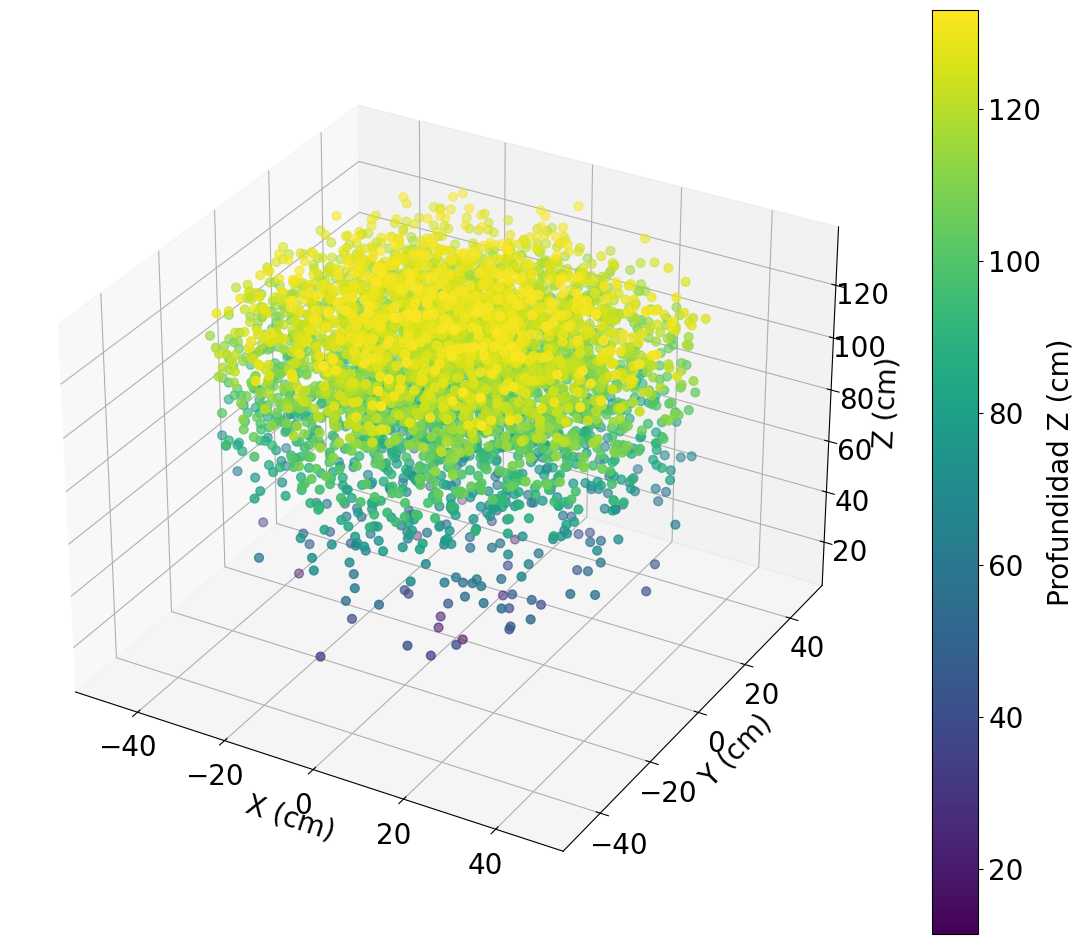

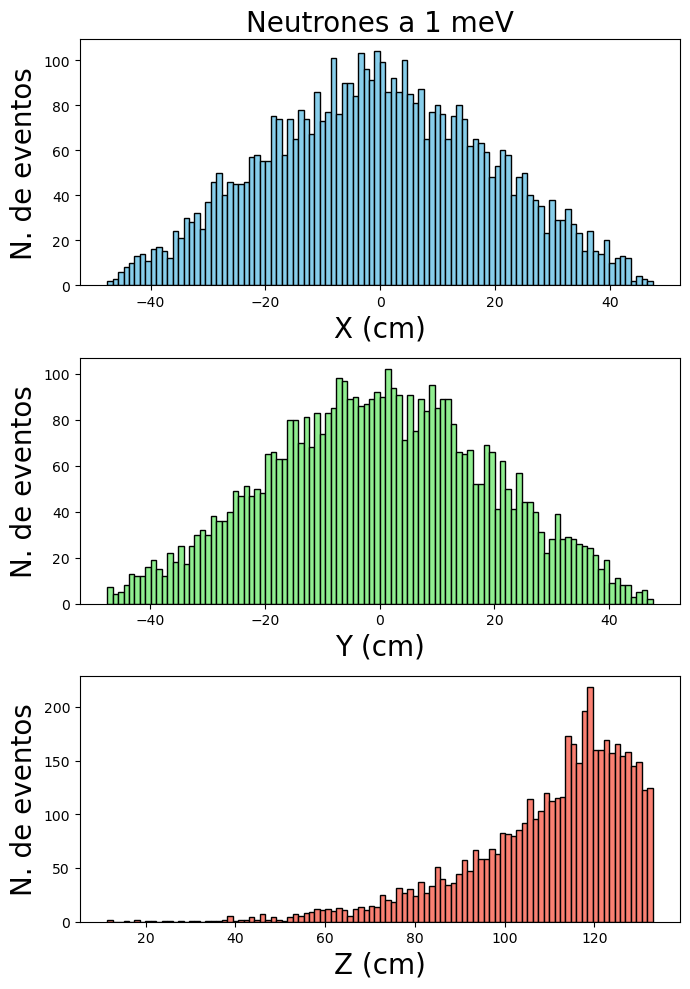

In [63]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Archivo de entrada
input_file = "fotoelectrico-completo-1meV.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            # Conversión de mm a cm
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

# ====== Gráfico 3D ======
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=40)

ax.set_xlabel("X (cm)", fontsize=20)
ax.set_ylabel("Y (cm)", fontsize=20)
ax.set_zlabel("Z (cm)", fontsize=20)
ax.set_title("", fontsize=16)
ax.tick_params(labelsize=20)  # Aplica a todos los ejes


# Colorbar con tamaño de letra modificado
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Profundidad Z (cm)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig('Coordenadas-Fotoelectrico-1meV.png', format='jpg')
plt.savefig('Coordenadas-Fotoelectrico-1meV.pdf', format='pdf')
plt.show()

# ====== Histogramas individuales ======
fig, axes = plt.subplots(3, 1, figsize=(7,10))

# Distribución en X
axes[0].hist(x, bins=100, color="skyblue", edgecolor="black")
axes[0].set_xlabel("X (cm)", fontsize=20)
axes[0].set_ylabel("N. de eventos", fontsize=20)
axes[0].set_title("Neutrones a 1 meV", fontsize=20)

# Distribución en Y
axes[1].hist(y, bins=100, color="lightgreen", edgecolor="black")
axes[1].set_xlabel("Y (cm)", fontsize=20)
axes[1].set_ylabel("N. de eventos", fontsize=20)
axes[1].set_title("", fontsize=14)

# Distribución en Z
axes[2].hist(z, bins=100, color="salmon", edgecolor="black")
axes[2].set_xlabel("Z (cm)", fontsize=20)
axes[2].set_ylabel("N. de eventos", fontsize=20)
axes[2].set_title("", fontsize=14)

plt.tight_layout()
plt.savefig('Histogramas.Coordenadas-Fotoelectrico-1meV.png', format='jpg')
plt.savefig('Histogramas.Coordenadas-Fotoelectrico-1meV.pdf', format='pdf')
plt.show()


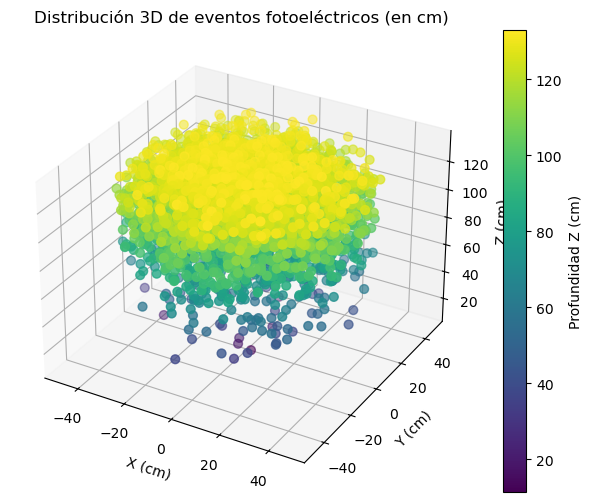

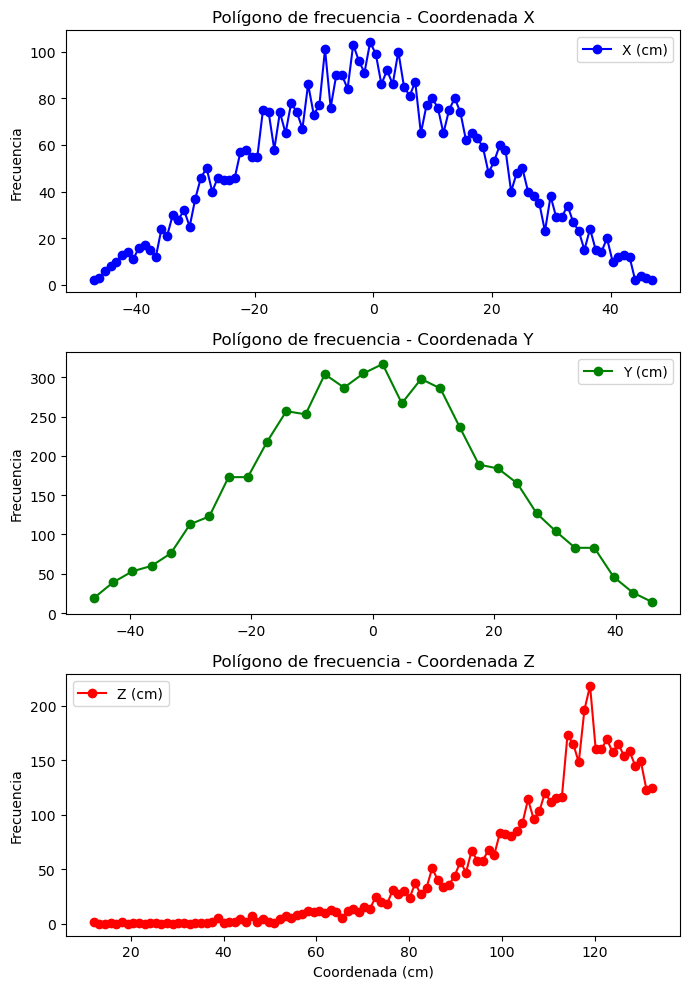

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Archivo de entrada
input_file = "fotoelectrico-completo-1meV.txt"

# Listas para almacenar coordenadas
x, y, z = [], [], []

# Leer el archivo
with open(input_file, "r") as f:
    for linea in f:
        columnas = linea.split()
        if len(columnas) >= 8 and columnas[4] == "phot":
            # Conversión de mm a cm
            x.append(float(columnas[5]) / 10.0)  # Columna 6
            y.append(float(columnas[6]) / 10.0)  # Columna 7
            z.append(float(columnas[7]) / 10.0)  # Columna 8

# ====== Gráfico 3D ======
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(x, y, z, c=z, cmap="viridis", marker="o", s=40)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.set_title("Distribución 3D de eventos fotoeléctricos (en cm)")

fig.colorbar(scatter, ax=ax, label="Profundidad Z (cm)")
plt.show()

# ====== Polígonos de frecuencia ======
fig, axes = plt.subplots(3, 1, figsize=(7,10))

# Función auxiliar para graficar polígono de frecuencia
def poligono_frecuencia(data, bins, ax, color, label):
    counts, bin_edges = np.histogram(data, bins=bins)
    # Puntos medios de cada bin
    mids = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    ax.plot(mids, counts, color=color, marker="o", linestyle="-", label=label)
    ax.set_ylabel("Frecuencia")
    ax.legend()

# Distribución en X
poligono_frecuencia(x, bins=100, ax=axes[0], color="blue", label="X (cm)")
axes[0].set_title("Polígono de frecuencia - Coordenada X")

# Distribución en Y
poligono_frecuencia(y, bins=30, ax=axes[1], color="green", label="Y (cm)")
axes[1].set_title("Polígono de frecuencia - Coordenada Y")

# Distribución en Z
poligono_frecuencia(z, bins=100, ax=axes[2], color="red", label="Z (cm)")
axes[2].set_title("Polígono de frecuencia - Coordenada Z")

plt.xlabel("Coordenada (cm)")
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Se guardaron 4175 valores en energia-fotones-fotoelectrico-AP-1meV.txt
Media: 0.0667, Desviación estándar: 0.1102
Media en 0.01–0.1 MeV: 0.0464
Desviación estándar en 0.01–0.1 MeV: 0.0151


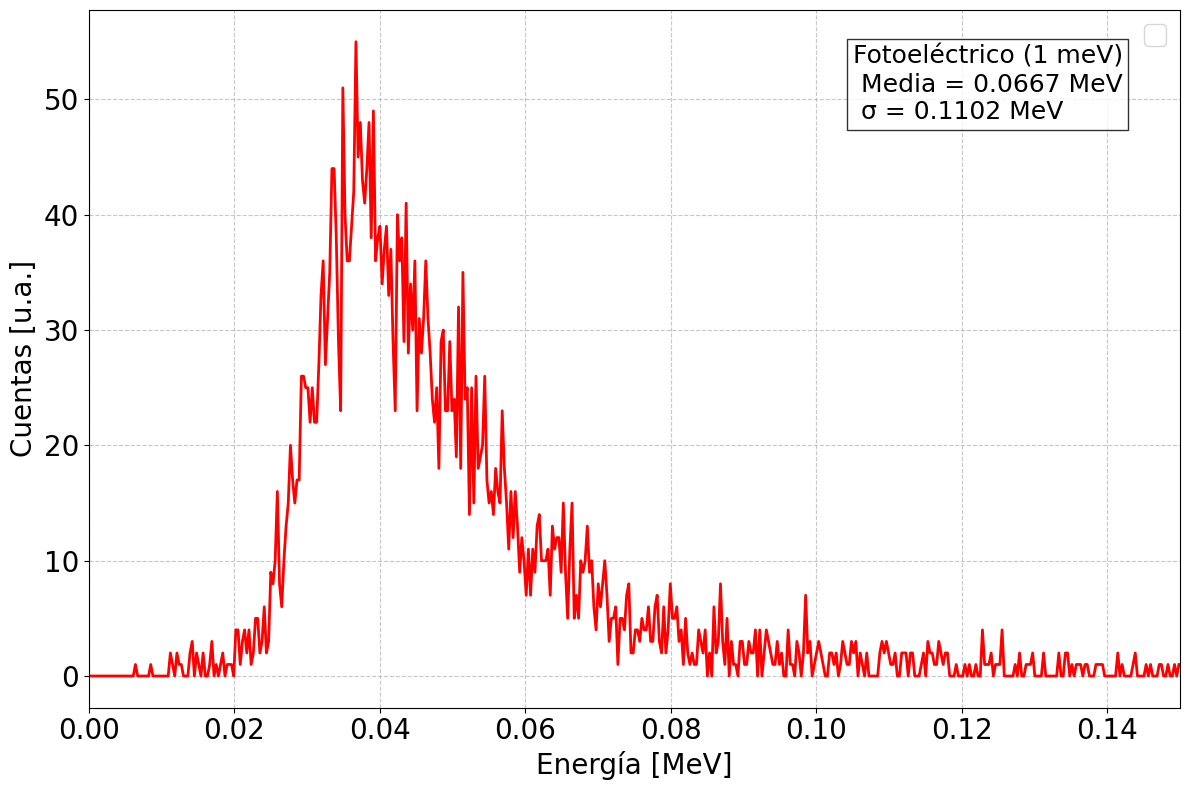

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Archivos
input_file = "gamma-limpio-AP-1meV.txt"
output_file = "energia-fotones-fotoelectrico-AP-1meV.txt"

valores = []

# Leer el archivo línea por línea
with open(input_file, "r") as f:
    lineas = f.readlines()

# Recorrer con índice
for i in range(1, len(lineas)):
    columnas = lineas[i].split()
    if len(columnas) >= 5 and columnas[4] == "phot":
        # Retroceder una fila
        prev_columnas = lineas[i - 1].split()
        if len(prev_columnas) >= 9 and prev_columnas[4] == "compt":
            valor = float(prev_columnas[8])  # Columna 9 (índice 8 en Python)
            valores.append(valor)

# Guardar en archivo
with open(output_file, "w") as f:
    for v in valores:
        f.write(f"{v}\n")

print(f"Se guardaron {len(valores)} valores en {output_file}")

# -------------------------
# Cálculo de estadísticos
# -------------------------
media = np.mean(valores)
desv = np.std(valores)
print(f"Media: {media:.4f}, Desviación estándar: {desv:.4f}")

# -------------------------
# CONFIGURACIÓN DEL HISTOGRAMA COMO POLÍGONO DE FRECUENCIA
# -------------------------

numero_bins = 500
inicio, fin = 0, 0.15


def plot_polygon(data, color, label):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos obtenidos del archivo
plot_polygon(valores, color='red', label='')

# Agregar etiquetas y formato
plt.xlabel('Energía [MeV]', fontsize=20)
plt.ylabel('Cuentas [u.a.]', fontsize=20)
plt.xlim(0, 0.15)   # Ajusta rango según tus datos
plt.xticks(np.arange(0, 0.15, 0.02))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)

# -------------------------
# Cálculo de estadísticos en un intervalo (0.02–0.10 MeV)
# -------------------------
intervalo = [0.01, 0.10]
valores_intervalo = [v for v in valores if intervalo[0] <= v <= intervalo[1]]

if len(valores_intervalo) > 0:
    media_intervalo = np.mean(valores_intervalo)
    desv_intervalo = np.std(valores_intervalo)
    print(f"Media en {intervalo[0]}–{intervalo[1]} MeV: {media_intervalo:.4f}")
    print(f"Desviación estándar en {intervalo[0]}–{intervalo[1]} MeV: {desv_intervalo:.4f}")
else:
    print("No hay valores en el intervalo definido.")


# Agregar leyenda
plt.legend(fontsize=20)

# Texto adicional con resultados estadísticos
texto = f"Fotoeléctrico (1 meV)\n Media = {media:.4f} MeV\n σ = {desv:.4f} MeV"
plt.text(
    0.7, 0.95,
    texto,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)




# Guardar y mostrar
plt.tight_layout()
plt.savefig('Espectro-Fotoelectrico-1meV.png', format='jpg')
plt.savefig('Espectro-Fotoelectrico-1meV.pdf', format='pdf')
plt.show()


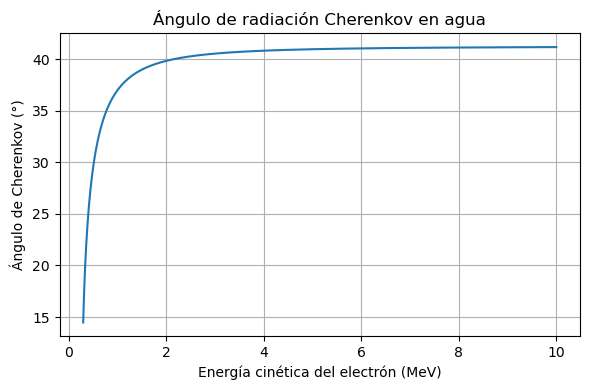

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Índice de refracción del agua
n = 1.33
# Rango de energías cinéticas en MeV
E = np.linspace(0.3, 10, 1000)
# Masa del electrón en MeV
m_e = 0.511
# Velocidad (beta)
beta = np.sqrt(1 - (1 / ((E / m_e) + 1)**2))
# Ángulo de Cherenkov
theta_c = np.arccos(1 / (n * beta)) * 180 / np.pi

plt.figure(figsize=(6, 4))
plt.plot(E, theta_c)
plt.xlabel('Energía cinética del electrón (MeV)')
plt.ylabel('Ángulo de Cherenkov (°)')
plt.title('Ángulo de radiación Cherenkov en agua')
plt.grid()
plt.tight_layout()
plt.savefig('angulo_cherenkov.png', dpi=300)
plt.show()



--- Estadísticas de procesos ---
3: 125915 ocurrencias
20: 81 ocurrencias
19: 95 ocurrencias
112: 26 ocurrencias
10: 77 ocurrencias
154: 6 ocurrencias
46: 79 ocurrencias
193: 4 ocurrencias
109: 12 ocurrencias
30: 26 ocurrencias
32: 21 ocurrencias
8: 233 ocurrencias
7: 527 ocurrencias
53: 74 ocurrencias
52: 88 ocurrencias
59: 55 ocurrencias
16: 82 ocurrencias
100: 46 ocurrencias
167: 10 ocurrencias
96: 18 ocurrencias
9: 63 ocurrencias
25: 31 ocurrencias
174: 14 ocurrencias
5: 263 ocurrencias
108: 32 ocurrencias
118: 34 ocurrencias
17: 103 ocurrencias
4: 146 ocurrencias
2: 254 ocurrencias
6: 517 ocurrencias
92: 16 ocurrencias
23: 79 ocurrencias
43: 37 ocurrencias
42: 29 ocurrencias
173: 17 ocurrencias
242: 1 ocurrencias
114: 19 ocurrencias
183: 5 ocurrencias
123: 33 ocurrencias
194: 2 ocurrencias
181: 11 ocurrencias
18: 105 ocurrencias
189: 16 ocurrencias
237: 1 ocurrencias
73: 41 ocurrencias
40: 84 ocurrencias
39: 50 ocurrencias
24: 55 ocurrencias
15: 116 ocurrencias
175: 6 ocurrencias

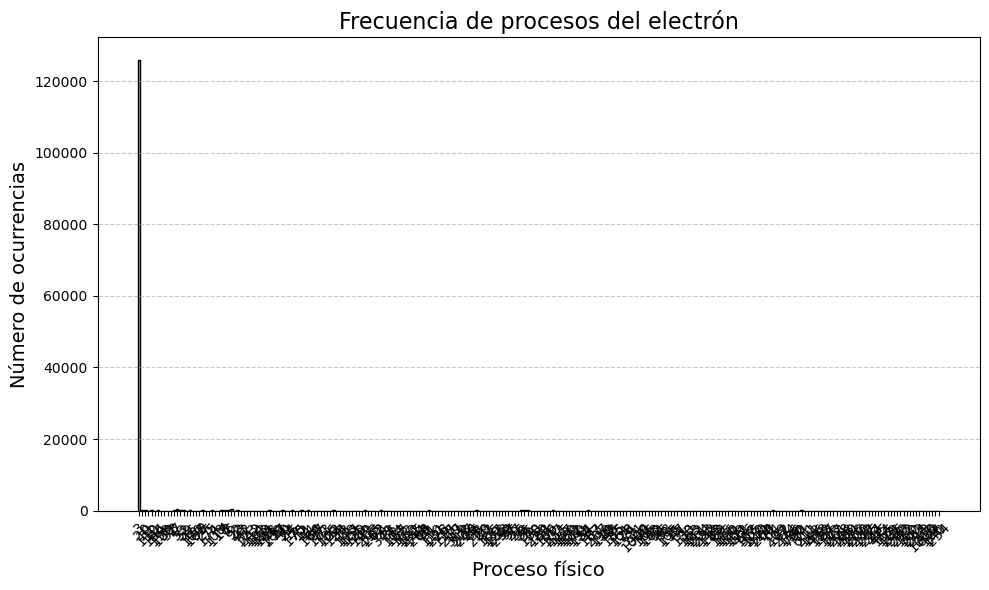

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Nombre del archivo
archivo = "gamma-completo.txt"

# Lista para almacenar los nombres de procesos
procesos = []

# Leer el archivo y extraer la columna 2 (índice 1)
with open(archivo, "r") as f:
    for linea in f:
        partes = linea.strip().split()
        if len(partes) >= 2:
            procesos.append(partes[1])

# Contar la frecuencia de cada proceso
conteo_procesos = Counter(procesos)

# Mostrar estadísticas
print("\n--- Estadísticas de procesos ---")
for proceso, cantidad in conteo_procesos.items():
    print(f"{proceso}: {cantidad} ocurrencias")

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(conteo_procesos.keys(), conteo_procesos.values(), color='skyblue', edgecolor='black')
plt.title("Frecuencia de procesos del electrón", fontsize=16)
plt.xlabel("Proceso físico", fontsize=14)
plt.ylabel("Número de ocurrencias", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar gráfico
plt.tight_layout()
plt.savefig("procesos-electron.png", dpi=300)
plt.savefig("procesos-electron.pdf")
plt.show()


===== Estadísticas de Procesos Físicos (filtrados por coordenadas) =====
Total de eventos: 267747
Promedio de ocurrencias por proceso: 38249.57
Proceso más frecuente: eIoni (104415 veces)
Proceso menos frecuente: annihil (3 veces)


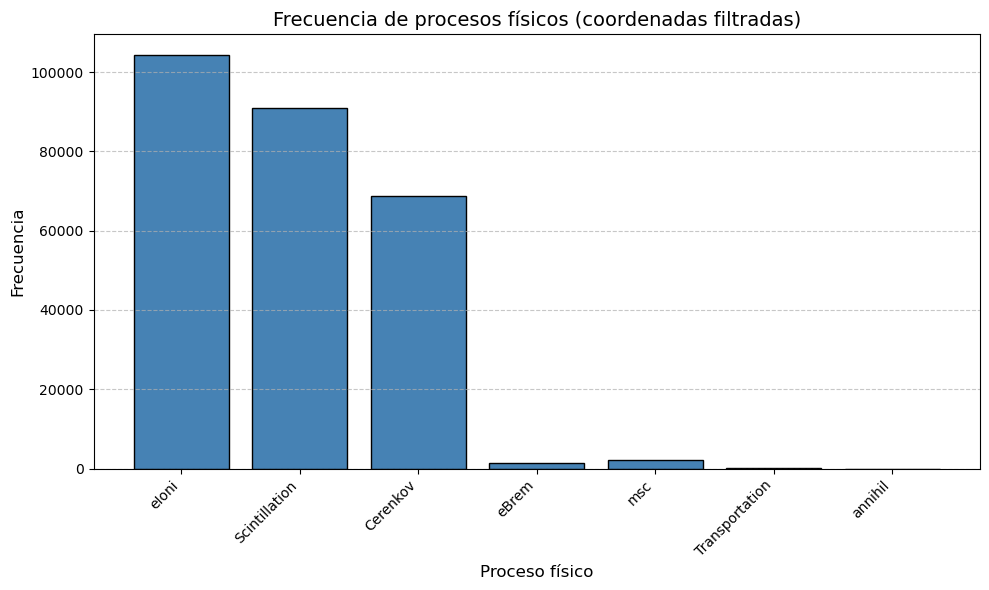

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# Rango permitido para cada coordenada
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Lista para almacenar los procesos válidos
procesos_filtrados = []

# Archivo de entrada
archivo = "rastreo-electron.txt"

# Leer y filtrar el archivo
with open(archivo, "r") as f:
    for linea in f:
        partes = linea.strip().split()
        if len(partes) >= 8:
            try:
                x = float(partes[5])
                y = float(partes[6])
                z = float(partes[7])
                proceso = partes[1]
                
                # Verificar filtros
                if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
                    procesos_filtrados.append(proceso)
            except ValueError:
                continue

# Contar ocurrencias de cada proceso
conteo_procesos = Counter(procesos_filtrados)

# Estadísticas básicas
total_eventos = sum(conteo_procesos.values())
promedio = total_eventos / len(conteo_procesos) if conteo_procesos else 0
proceso_mas_frecuente = conteo_procesos.most_common(1)[0] if conteo_procesos else ("N/A", 0)
proceso_menos_frecuente = min(conteo_procesos.items(), key=lambda x: x[1]) if conteo_procesos else ("N/A", 0)

# Mostrar estadísticas
print("===== Estadísticas de Procesos Físicos (filtrados por coordenadas) =====")
print(f"Total de eventos: {total_eventos}")
print(f"Promedio de ocurrencias por proceso: {promedio:.2f}")
print(f"Proceso más frecuente: {proceso_mas_frecuente[0]} ({proceso_mas_frecuente[1]} veces)")
print(f"Proceso menos frecuente: {proceso_menos_frecuente[0]} ({proceso_menos_frecuente[1]} veces)")

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(conteo_procesos.keys(), conteo_procesos.values(), color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Proceso físico", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Frecuencia de procesos físicos (coordenadas filtradas)", fontsize=14)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig("frecuencia_procesos_filtrados.png", dpi=300)
plt.show()



Resumen de procesos encontrados:
compt: 80358 eventos
phot: 5273 eventos
Transportation: 9239 eventos
conv: 151 eventos
Rayl: 3453 eventos

Tabla en LaTeX:
\begin{table}[h!]
\centering
\begin{tabular}{|c|c|}
\hline
\textbf{Proceso} & \textbf{Conteo} \\ \hline
compt & 80358 \\ \hline
phot & 5273 \\ \hline
Transportation & 9239 \\ \hline
conv & 151 \\ \hline
Rayl & 3453 \\ \hline
\end{tabular}
\caption{Conteo de eventos por proceso (filtrados por volumen)}
\label{{tabla:conteo_procesos}}
\end{table}


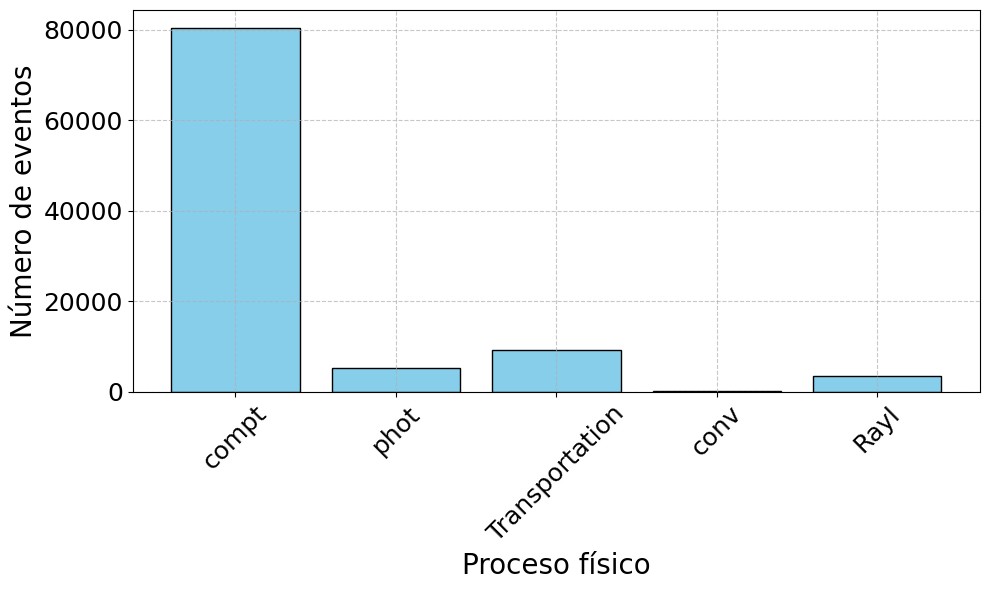

In [7]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Archivos
archivo_entrada = "gamma-completo.txt"
carpeta_salida = "procesos_filtrados"
os.makedirs(carpeta_salida, exist_ok=True)

# Condiciones espaciales
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Contadores
procesos = Counter()
lineas_por_proceso = {}

# Leer y filtrar
with open(archivo_entrada, 'r') as archivo:
    for linea in archivo:
        partes = linea.strip().split()
        if len(partes) < 8:
            continue
        try:
            x, y, z = float(partes[5]), float(partes[6]), float(partes[7])
        except ValueError:
            continue
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            proceso = partes[4]
            procesos[proceso] += 1
            lineas_por_proceso.setdefault(proceso, []).append(linea)

# Guardar en archivos separados por proceso
for proceso, lineas in lineas_por_proceso.items():
    with open(os.path.join(carpeta_salida, f"{proceso}.txt"), "w") as f:
        f.writelines(lineas)

# Mostrar conteo
print("\nResumen de procesos encontrados:")
for proceso, cantidad in procesos.items():
    print(f"{proceso}: {cantidad} eventos")

# Tabla en LaTeX
print("\nTabla en LaTeX:")
print("\\begin{table}[h!]")
print("\\centering")
print("\\begin{tabular}{|c|c|}")
print("\\hline")
print("\\textbf{Proceso} & \\textbf{Conteo} \\\\ \\hline")
for proceso, cantidad in procesos.items():
    print(f"{proceso} & {cantidad} \\\\ \\hline")
print("\\end{tabular}")
print("\\caption{Conteo de eventos por proceso (filtrados por volumen)}")
print("\\label{{tabla:conteo_procesos}}")
print("\\end{table}")

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(procesos.keys(), procesos.values(), color='skyblue', edgecolor='black')
plt.xlabel("Proceso físico", fontsize=20)
plt.ylabel("Número de eventos", fontsize=20)
plt.title("", fontsize=16)
plt.grid(True)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=18)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=18)  # Tics mayores
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("procesos-gamma-agua-pura-1meV.png")
plt.show()



Tabla en LaTeX:
\begin{table}[h!]
\centering
\begin{tabular}{|c|c|}
\hline
\textbf{Proceso} & \textbf{Conteo} \\ \hline
compt & 80358 \\ \hline
phot & 5273 \\ \hline
Transportation & 9239 \\ \hline
conv & 151 \\ \hline
Rayl & 3453 \\ \hline
\end{tabular}
\caption{Conteo de eventos por proceso (filtrados por volumen)}
\label{{tabla:conteo_procesos}}
\end{table}


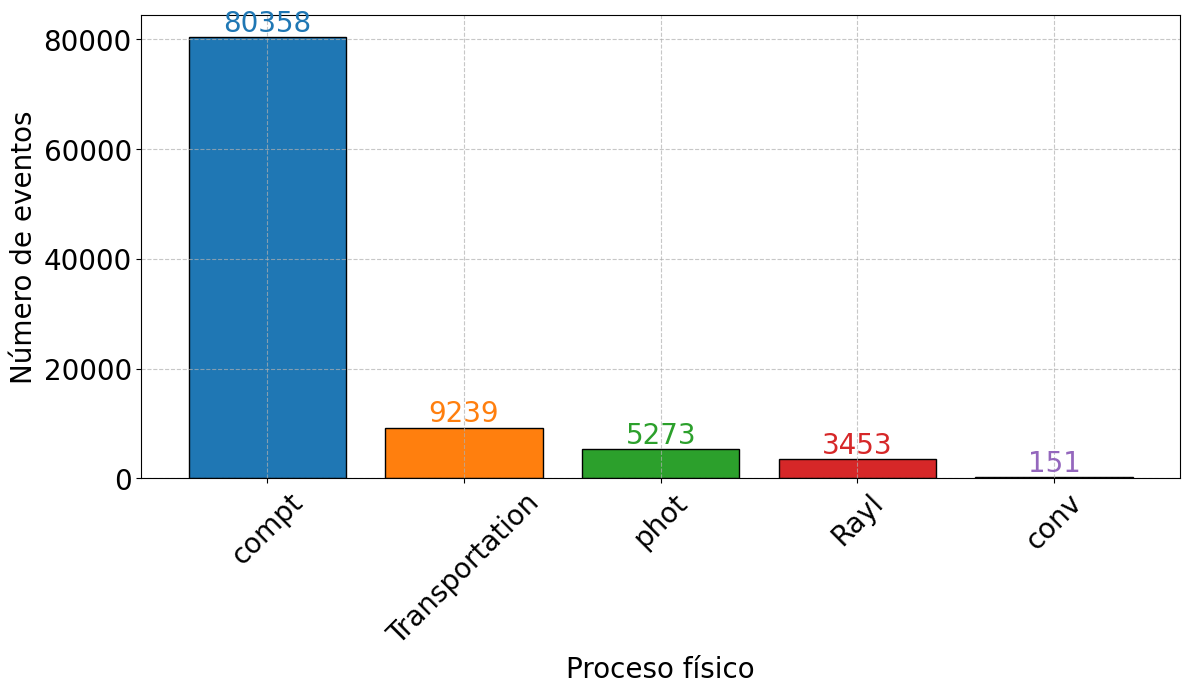

In [9]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# Archivos
archivo_entrada = "gamma-completo-AP-1meV.txt"
carpeta_salida = "procesos_filtrados"
os.makedirs(carpeta_salida, exist_ok=True)

# Condiciones espaciales
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Contadores
procesos = Counter()
lineas_por_proceso = {}

# Leer y filtrar
with open(archivo_entrada, 'r') as archivo:
    for linea in archivo:
        partes = linea.strip().split()
        if len(partes) < 8:
            continue
        try:
            x, y, z = float(partes[5]), float(partes[6]), float(partes[7])
        except ValueError:
            continue
        if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
            proceso = partes[4]
            procesos[proceso] += 1
            lineas_por_proceso.setdefault(proceso, []).append(linea)

# Guardar en archivos separados por proceso
for proceso, lineas in lineas_por_proceso.items():
    with open(os.path.join(carpeta_salida, f"{proceso}.txt"), "w") as f:
        f.writelines(lineas)

# Tabla LaTeX
print("\nTabla en LaTeX:")
print("\\begin{table}[h!]")
print("\\centering")
print("\\begin{tabular}{|c|c|}")
print("\\hline")
print("\\textbf{Proceso} & \\textbf{Conteo} \\\\ \\hline")
for proceso, cantidad in procesos.items():
    print(f"{proceso} & {cantidad} \\\\ \\hline")
print("\\end{tabular}")
print("\\caption{Conteo de eventos por proceso (filtrados por volumen)}")
print("\\label{{tabla:conteo_procesos}}")
print("\\end{table}")

# Gráfico de barras mejorado
plt.figure(figsize=(12, 7))
procesos_ordenados = procesos.most_common()
procesos_nombres = [p[0] for p in procesos_ordenados]
procesos_cantidades = [p[1] for p in procesos_ordenados]
colores = plt.cm.tab10(range(len(procesos)))  # hasta 10 colores distintos

barras = plt.bar(procesos_nombres, procesos_cantidades, color=colores, edgecolor='black')

# Añadir texto encima de cada barra
for i, bar in enumerate(barras):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             #f"{procesos_nombres[i]}\n{procesos_cantidades[i]}",
             f"{procesos_cantidades[i]}",
             ha='center', va='bottom',
             fontsize=20,
             color=bar.get_facecolor())

plt.xlabel("Proceso físico", fontsize=20)
plt.ylabel("Número de eventos", fontsize=20)
plt.title("", fontsize=16)
plt.grid(True)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("procesos-gamma-agua-pura-1meV.png", dpi=300)
plt.show()


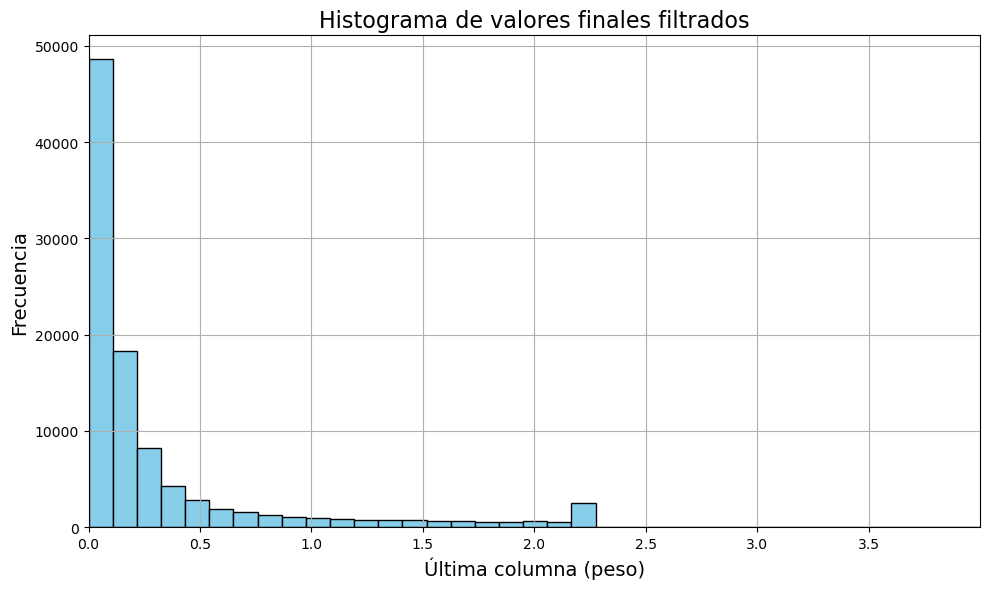

Valor mínimo de z (columna 9): 0.0
Valor máximo de z (columna 9): 1330.0


In [9]:
import matplotlib.pyplot as plt

# Límites de filtrado
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Ruta al archivo
archivo = 'gamma-completo.txt'

# Listas para almacenar valores filtrados
ultimos_valores = []
valores_z = []

# Leer archivo línea por línea
with open(archivo, 'r') as file:
    for linea in file:
        partes = linea.strip().split()
        if len(partes) >= 9:
            try:
                x = float(partes[5])
                y = float(partes[6])
                z = float(partes[7])
                ultimo_valor = float(partes[8])
                if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
                    ultimos_valores.append(ultimo_valor)
                    valores_z.append(z)
            except ValueError:
                continue  # En caso de que haya líneas mal formateadas

# Verificar si hay datos
if ultimos_valores:
    # Graficar histograma
    plt.figure(figsize=(10, 6))
    plt.hist(ultimos_valores, bins=100, color='skyblue', edgecolor='black')
    plt.xlabel('Última columna (peso)', fontsize=14)
    plt.xlim(0, 4)
    plt.xticks(np.arange(0, 4, 0.5))
    plt.ylabel('Frecuencia', fontsize=14)
    plt.title('Histograma de valores finales filtrados', fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Mínimo y máximo de la columna 9 (z)
    print(f'Valor mínimo de z (columna 9): {min(valores_z)}')
    print(f'Valor máximo de z (columna 9): {max(valores_z)}')
else:
    print("No se encontraron datos que cumplan con los criterios.")


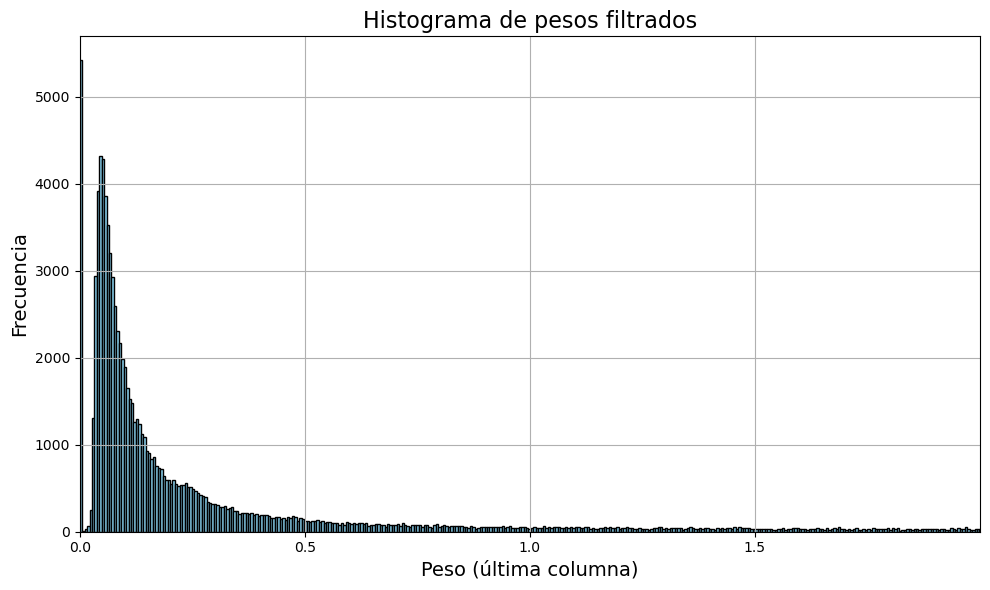

Valor mínimo de pesos: 0.0
Valor máximo de pesos: 10.8333


In [53]:
import matplotlib.pyplot as plt

# Límites de filtrado
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Ruta al archivo
archivo = 'gamma-completo.txt'

# Listas para almacenar valores filtrados
pesos = []
z_vals = []

# Leer archivo línea por línea
with open(archivo, 'r') as file:
    for linea in file:
        partes = linea.strip().split()
        if len(partes) >= 8:
            try:
                x = float(partes[5])
                y = float(partes[6])
                z = float(partes[7])  # columna 9
                peso = float(partes[8])  # última columna
                if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
                    pesos.append(peso)
                    #z_vals.append(z)
            except ValueError:
                continue  # Omitir líneas mal formateadas

# Verificar si hay datos
if pesos:
    # Graficar histograma
    plt.figure(figsize=(10, 6))
    plt.hist(pesos, bins=2000, color='skyblue', edgecolor='black')
    plt.xlabel('Peso (última columna)', fontsize=14)
    plt.xlim(0, 2)
    plt.xticks(np.arange(0, 2, 0.5))
    plt.ylabel('Frecuencia', fontsize=14)
    plt.title('Histograma de pesos filtrados', fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    min_peso = min(pesos)
    max_peso = max(pesos)

    print(f"Valor mínimo de pesos: {min_peso}")
    print(f"Valor máximo de pesos: {max_peso}")

else:
    print("No se encontraron datos que cumplan con los criterios.")


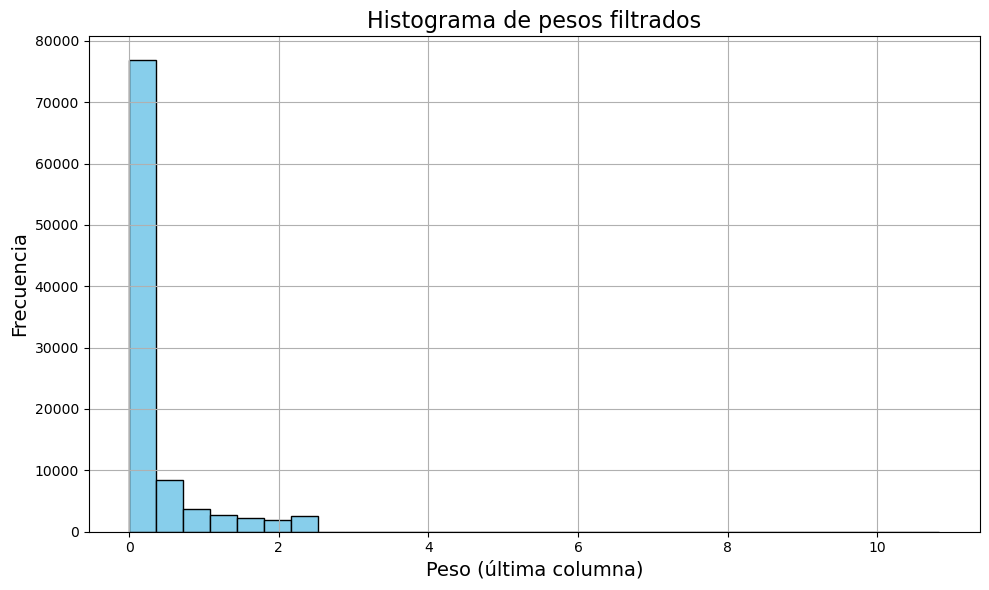

Valor mínimo de pesos: 0.0
Valor máximo de pesos: 10.8333


In [49]:
import matplotlib.pyplot as plt

# Límites de filtrado
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.0

# Ruta al archivo original
archivo = 'gamma-completo.txt'

# Archivo de salida
archivo_salida = 'gama-energia.txt'

# Listas para almacenar valores filtrados
pesos = []
z_vals = []

# Leer archivo línea por línea y escribir las z válidas
with open(archivo, 'r') as file, open(archivo_salida, 'w') as salida:
    for linea in file:
        partes = linea.strip().split()
        if len(partes) >= 8:
            try:
                x = float(partes[5])
                y = float(partes[6])
                z = float(partes[7])  # columna 9
                peso = float(partes[8])  # última columna
                if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
                    pesos.append(peso)
                    #z_vals.append(z)
                    salida.write(f"{peso}\n")  # Escribir solo columna 9
            except ValueError:
                continue  # Omitir líneas mal formateadas

# Verificar si hay datos
if pesos:
    # Graficar histograma
    plt.figure(figsize=(10, 6))
    plt.hist(pesos, bins=30, color='skyblue', edgecolor='black')
    plt.xlabel('Peso (última columna)', fontsize=14)
    plt.ylabel('Frecuencia', fontsize=14)
    plt.title('Histograma de pesos filtrados', fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    min_peso = min(pesos)
    max_peso = max(pesos)

    print(f"Valor mínimo de pesos: {min_peso}")
    print(f"Valor máximo de pesos: {max_peso}")
else:
    print("No se encontraron datos que cumplan con los criterios.")


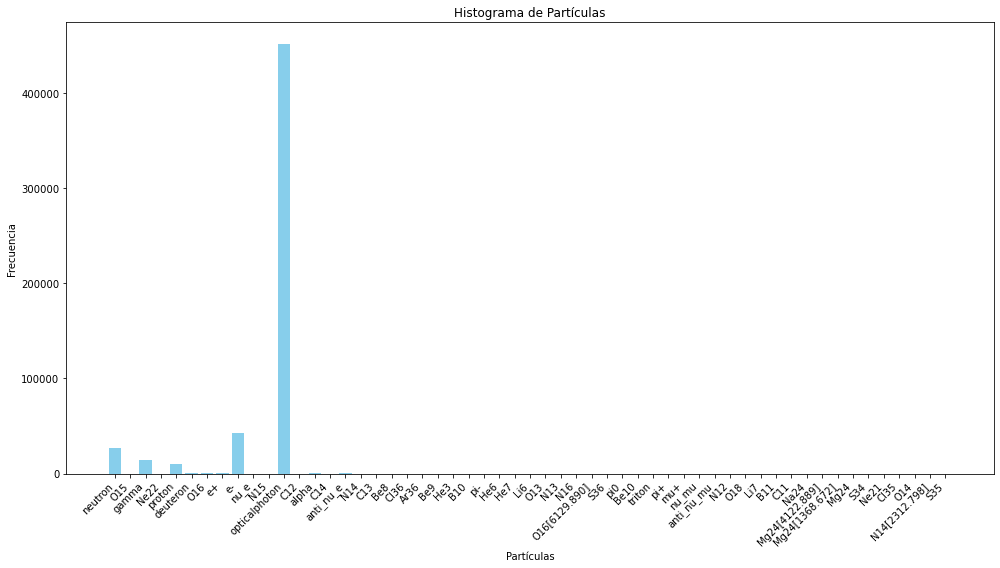

In [11]:
import matplotlib.pyplot as plt
from collections import Counter

# Nombre del archivo de entrada
archivo_entrada = 'rastreo-completo.txt'

# Diccionario para almacenar el recuento de cada partícula
recuento_particulas = Counter()

# Leer el archivo y contar ocurrencias de cada partícula
with open(archivo_entrada, 'r') as archivo:
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        # Obtener la partícula de la primera columna
        particula = columnas[0]
        # Incrementar la frecuencia de la partícula
        recuento_particulas[particula] += 1

# Configurar los datos para el gráfico de barras
nombres_particulas = list(recuento_particulas.keys())
recuento = list(recuento_particulas.values())

# Crear el histograma
plt.figure(figsize=(14, 8))  # Ajustar el tamaño del gráfico según sea necesario
plt.bar(nombres_particulas, recuento, color='skyblue')
plt.xlabel('Partículas')
plt.ylabel('Frecuencia')
plt.title('Histograma de Partículas')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mayor legibilidad
plt.tight_layout()  # Ajustar el diseño para evitar cortar las etiquetas
plt.show()



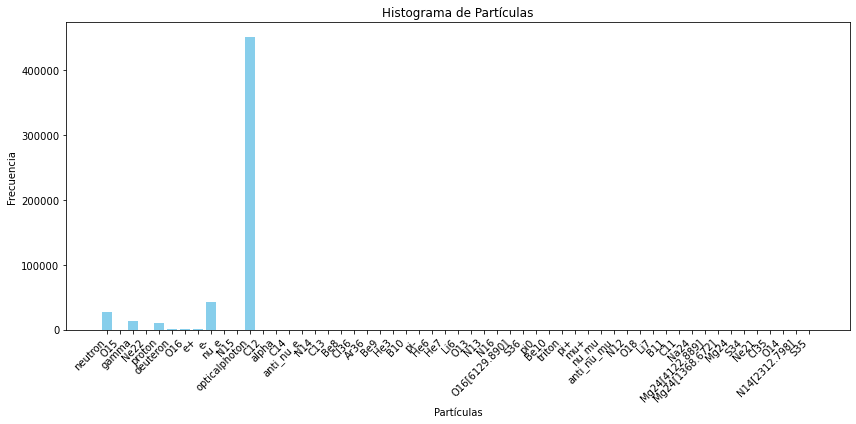

In [19]:
import matplotlib.pyplot as plt
from collections import Counter

# Nombre del archivo de entrada
archivo_entrada = 'rastreo-completo.txt'

# Diccionario para almacenar el recuento de cada partícula
recuento_particulas = Counter()

# Leer el archivo y contar ocurrencias de cada partícula
with open(archivo_entrada, 'r') as archivo:
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        # Obtener la partícula de la primera columna
        particula = columnas[0]
        # Incrementar la frecuencia de la partícula
        recuento_particulas[particula] += 1

# Configurar los datos para el gráfico de barras
nombres_particulas = list(recuento_particulas.keys())
recuento = list(recuento_particulas.values())

# Crear el histograma
plt.figure(figsize=(12, 6))  # Ajustar el tamaño del gráfico según sea necesario
bars = plt.bar(nombres_particulas, recuento, color='skyblue')
plt.xlabel('Partículas')
plt.ylabel('Frecuencia')
plt.title('Histograma de Partículas')
plt.xticks(rotation=45, ha='right')  # Rotar las etiquetas del eje x para mayor legibilidad

# Etiquetas y porcentajes
#for bar, nombre, valor in zip(bars, nombres_particulas, recuento):
    # Calcular posición para etiqueta y porcentaje
#    x, y = bar.get_xy()
    #plt.text(x + bar.get_width() + 0.2, y + bar.get_height() / 2, f'{nombre}\nN° entradas: {valor}',
     #        fontsize=8, va='center', bbox=dict(facecolor='lightgray', alpha=0.5))
#    plt.text(1.90, 0.30,f'{nombre}\nN° entradas: {valor}',fontsize=8, va='center', bbox=dict(facecolor='lightgray', alpha=0.5))

plt.tight_layout()  # Ajustar el diseño para evitar cortar las etiquetas
plt.show()

In [12]:
import pandas as pd
from collections import Counter

# Nombre del archivo de entrada
archivo_entrada = 'rastreo-completo.txt'

# Leer el archivo y contar ocurrencias de cada partícula
with open(archivo_entrada, 'r') as archivo:
    # Dividir las líneas en columnas y tomar la primera columna
    particulas = [linea.split()[0] for linea in archivo]

# Contar ocurrencias de cada partícula
recuento_particulas = Counter(particulas)

# Convertir el recuento a un DataFrame de pandas
df = pd.DataFrame(list(recuento_particulas.items()), columns=['Partícula', 'N° Entradas'])

# Calcular el porcentaje
df['Porcentaje'] = (df['N° Entradas'] / df['N° Entradas'].sum()) * 100

# Mostrar la tabla
print(df)

         Partícula  N° Entradas  Porcentaje
0          neutron        27331    4.971361
1              O15           66    0.012005
2            gamma        14089    2.562713
3             Ne22            2    0.000364
4           proton        10325    1.878062
5         deuteron          496    0.090220
6              O16          786    0.142969
7               e+          816    0.148426
8               e-        42695    7.765989
9             nu_e          148    0.026920
10             N15          154    0.028012
11   opticalphoton       451447   82.115761
12             C12          102    0.018553
13           alpha          264    0.048020
14             C14           26    0.004729
15       anti_nu_e          229    0.041654
16             N14          138    0.025101
17             C13           62    0.011277
18             Be8           20    0.003638
19            Cl36          112    0.020372
20            Ar36          110    0.020008
21             Be9            2 

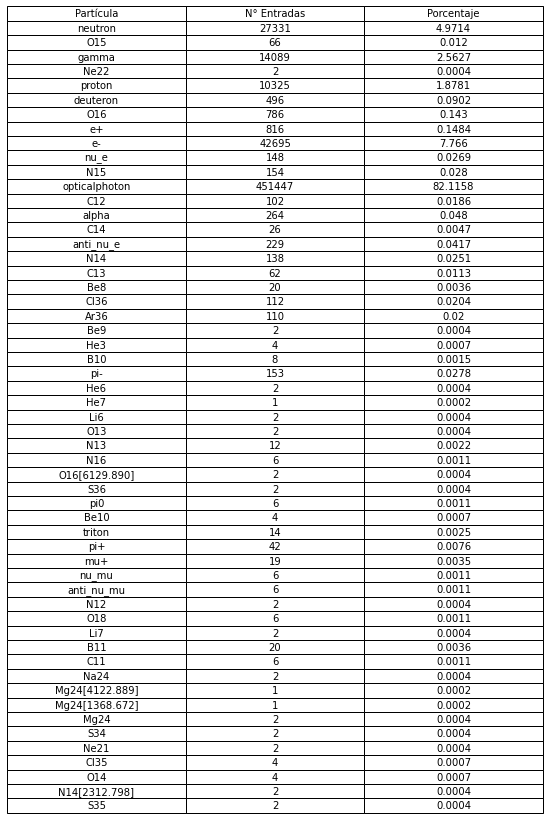

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Nombre del archivo de entrada
archivo_entrada = 'rastreo-completo.txt'

# Leer el archivo y contar ocurrencias de cada partícula
with open(archivo_entrada, 'r') as archivo:
    # Dividir las líneas en columnas y tomar la primera columna
    particulas = [linea.split()[0] for linea in archivo]

# Contar ocurrencias de cada partícula
recuento_particulas = Counter(particulas)

# Convertir el recuento a un DataFrame de pandas
df = pd.DataFrame(list(recuento_particulas.items()), columns=['Partícula', 'N° Entradas'])

# Calcular el porcentaje
#df['Porcentaje'] = (df['N° Entradas'] / df['N° Entradas'].sum()) * 100
df['Porcentaje'] = ((df['N° Entradas'] / df['N° Entradas'].sum()) * 100).round(4)
# Mostrar la tabla
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')  # Ocultar los ejes

tabla = ax.table(cellText=df.values, colLabels=df.columns, cellLoc = 'center', loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.2)  # Ajustar el tamaño de la tabla
# Ajustar el tamaño de la figura al de la tabla
#fig.tight_layout()
pdf_filename_stat_charge = 'Particulas-presentes.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Particulas-presentes.jpg', format='jpg')

plt.show()

Etiqueta        1      2      3      4      5      6      7      8      9      \
Particula                                                                       
Ar36                0      0      0      0      0      0      0      0      0   
B10                 0      0      0      0      0      0      0      0      0   
B11                 0      0      0      0      0      2      0      0      2   
Be10                0      0      0      0      0      0      0      0      0   
Be8                 0      0      0      0      0      0      0      0      2   
Be9                 0      0      0      0      0      0      0      0      0   
C11                 0      0      0      0      0      0      0      0      0   
C12                 0      0      0      0      2      0      4      8     14   
C13                 0      0      0      0      0      2      6      6      4   
C14                 0      0      0      0      0      0      4      2      0   
Cl35                0      0

KeyboardInterrupt: 

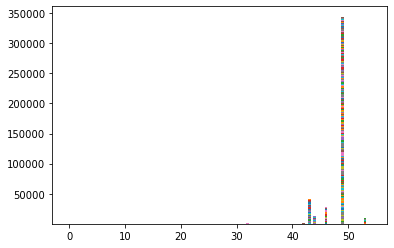

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer el archivo y darle nombres a las columnas
archivo_entrada = 'rastreo-completo.txt'  # Reemplaza con el nombre de tu archivo
column_names = ['Particula', 'Etiqueta', 'Col3', 'Col4', 'Col5', 'Col6', 'Col7']
df = pd.read_csv(archivo_entrada, delim_whitespace=True, names=column_names)

# Crear una tabla dinámica con recuento de entradas para cada combinación de Particula y Etiqueta
tabla = pd.pivot_table(df, values='Col3', index=['Particula'], columns=['Etiqueta'], aggfunc='count', fill_value=0)

# Mostrar la tabla
print(tabla)

# Guardar la tabla como un archivo CSV si es necesario
tabla.to_csv('tabla_resultado.csv')

# Mostrar la tabla como un gráfico (opcional)
tabla.plot(kind='bar', stacked=True)
plt.xlabel('Particula')
plt.ylabel('Recuento')
plt.title('Recuento de Entradas por Particula y Etiqueta')
plt.show()

   Nombre Particula  Segundo Nombre (Neutrones, Numero 1)  Numero Total  \
0        hadElastic                                   282           282   
1    Transportation                                   124           124   
2  neutronInelastic                                   114           114   
3          nCapture                                     4             4   

   Porcentaje  
0   53.816794  
1   23.664122  
2   21.755725  
3    0.763359  


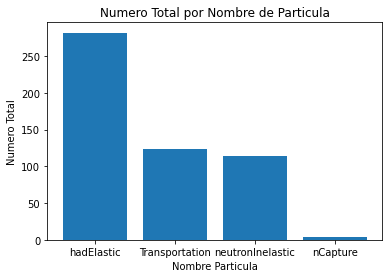

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Reemplaza 'tu_archivo.txt' con el nombre de tu archivo
archivo_entrada = 'rastreo-completo.txt'

# Leer el archivo y darle nombres a las columnas
column_names = ['Particula', 'Numero', 'Col3', 'Col4', 'Col5', 'Col6', 'Col7']
df = pd.read_csv(archivo_entrada, delim_whitespace=True, names=column_names)

# Filtrar solo las filas con 'neutron' y '1' en la columna 'Particula' y 'Numero'
filtro_neutron_1 = (df['Particula'] == 'neutron') & (df['Numero'] == 1)
df_filtrado = df[filtro_neutron_1]

# Contar el número de ocurrencias para cada nombre de particula
recuento_particulas = df_filtrado['Col3'].value_counts()

# Calcular el porcentaje
total = len(df_filtrado)
porcentajes = (recuento_particulas / total) * 100

# Crear un DataFrame con los resultados
df_resultado = pd.DataFrame({'Nombre Particula': recuento_particulas.index,
                              'Segundo Nombre (Neutrones, Numero 1)': recuento_particulas.values,
                              'Numero Total': recuento_particulas.values,
                              'Porcentaje': porcentajes.values})

# Mostrar la tabla
print(df_resultado)

# Guardar la tabla como un archivo CSV si es necesario
df_resultado.to_csv('resultado.csv', index=False)

# Visualizar la tabla como un gráfico (opcional)
plt.bar(df_resultado['Nombre Particula'], df_resultado['Numero Total'])
plt.xlabel('Nombre Particula')
plt.ylabel('Numero Total')
plt.title('Numero Total por Nombre de Particula')
plt.show()

In [26]:
# Nombre de tu archivo
archivo_entrada = 'rastreo-completo.txt'

# Diccionario para almacenar el recuento de partículas
recuento_particulas = {}

# Abrir el archivo y leer línea por línea
with open(archivo_entrada, 'r') as archivo:
    for linea in archivo:
        # Dividir la línea en columnas
        columnas = linea.split()
        
        # Verificar si la primera columna es 'neutron'
        if columnas[0] == 'neutron':
            # Verificar si la segunda columna es '1'
            if columnas[1] == '1':
                # Obtener el tipo de partícula de la tercera columna
                tipo_particula = columnas[0]
                
                # Incrementar el recuento en el diccionario
                recuento_particulas[tipo_particula] = recuento_particulas.get(tipo_particula, 0) + 1

# Mostrar el recuento de partículas
for tipo, recuento in recuento_particulas.items():
    print(f'{tipo}: {recuento} veces')


neutron: 524 veces
